# VisionGuard AI — Anomaly Detection

This notebook performs detailed **image-level anomaly detection** for the five selected MVTec AD categories using the category-specific CNN autoencoders produced by the VisionGuard training workflow.

The notebook is deliberately organized into many focused cells so each stage can be executed, inspected, debugged, and rerun independently.

### Core workflow
1. Validate the runtime and dependencies.
2. Discover the prepared dataset and trained category models without exposing filesystem locations in outputs.
3. Validate the model input/output contract.
4. Dynamically discover normal and defective test samples and their corresponding ground-truth masks.
5. Recreate the same deterministic normal validation split used during model training.
6. Calculate per-image reconstruction errors.
7. Calibrate category-specific thresholds from **normal validation images only**.
8. Apply thresholds to the test set.
9. Produce accuracy, precision, recall, F1-score, ROC-AUC and PR-AUC.
10. Analyze score distributions, threshold sensitivity, false positives and false negatives.
11. Generate reconstruction and error-map visualizations.
12. Export sanitized CSV reports that contain **no filesystem paths or locations**.
13. Save every visualization in the `images` folder using descriptive title-derived filenames.

## Detection philosophy

A convolutional autoencoder is trained primarily on normal examples. During inference, a normal image should be reconstructed relatively well, while an anomalous image is expected to produce a larger reconstruction discrepancy.

For image-level detection, the main score used here is:

$$
MSE(x,\hat{x}) = \frac{1}{N}\sum_{i=1}^{N}(x_i-\hat{x}_i)^2
$$

where `x` is the normalized input image and `x̂` is the reconstruction.

The threshold is calibrated independently for each category because every category has its own trained autoencoder and therefore its own natural reconstruction-error scale.

The primary threshold is the **99th percentile of normal validation reconstruction error**. Additional threshold rules are calculated for sensitivity analysis.

## Important output policy

This notebook intentionally keeps filesystem details internal.

- No absolute dataset or model paths are printed.
- No paths are included in displayed result tables.
- No path-like columns are written to CSV reports.
- Image references in reports use only the image filename.
- Visualizations are saved under the `images` folder using the figure title as the filename basis.
- Interactive Plotly figures are saved as HTML and, when the image exporter is available, PNG as well.

## Section A — Environment setup

### Install only the dependencies needed for anomaly detection

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "Pillow",
    "plotly": "plotly",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "cv2": "opencv-python",
    "kaleido": "kaleido",
}

missing_packages = [
    package
    for module_name, package in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing dependencies...")
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
        )
    except Exception as exc:
        raise RuntimeError(
            "Dependency installation failed. Resolve the package issue and rerun this cell."
        ) from exc
else:
    print("All required dependencies are already available.")

All required dependencies are already available.


### Import libraries

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import math
import re
import random
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

import cv2

import tensorflow as tf
from tensorflow import keras

ImageFile.LOAD_TRUNCATED_IMAGES = False
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Plotly:", __import__("plotly").__version__)

TensorFlow: 2.20.0
NumPy: 2.5.3
Pandas: 3.0.6
Plotly: 7.1.0


### Configure the project

In [3]:
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
IMAGE_CHANNELS = 3

VALIDATION_SIZE = 0.10
SEED = 42
PRIMARY_THRESHOLD_METHOD = "P99"

IMAGE_DIR = Path("images")
TABLE_DIR = Path("table")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Configuration initialized.")
print("Categories:", len(CATEGORIES))
print("Input resolution:", f"{IMAGE_WIDTH} × {IMAGE_HEIGHT}")
print("Primary threshold:", PRIMARY_THRESHOLD_METHOD)

Configuration initialized.
Categories: 5
Input resolution: 128 × 128
Primary threshold: P99


### Configure deterministic inference

In [4]:
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Deterministic TensorFlow operations requested where supported.")

Deterministic TensorFlow operations requested where supported.


### Check GPU availability

In [5]:
gpu_devices = tf.config.list_physical_devices("GPU")
print("GPU devices detected:", len(gpu_devices))
if gpu_devices:
    print("GPU inference is available.")
else:
    print("CPU inference will be used.")

GPU devices detected: 1
GPU inference is available.


## Section B — Safe reporting and visualization utilities

### Filename and report sanitization helpers

In [6]:
# Path-safe reporting and CSV export helpers

PATH_COLUMN_ALIASES = {
    "path",
    "filepath",
    "file path",
    "file_path",
    "image path",
    "image_path",
    "mask path",
    "mask_path",
    "ground truth path",
    "ground_truth_path",
    "gt path",
    "gt_path",
    "model path",
    "model_path",
    "dataset path",
    "dataset_path",
    "source path",
    "source_path",
    "output path",
    "output_path",
    "save path",
    "save_path",
    "cache path",
    "cache_path",
    "directory",
    "directory path",
    "directory_path",
    "folder",
    "folder path",
    "folder_path",
    "root path",
    "root_path",
}

PATH_PREFIXES = {
    "image",
    "file",
    "mask",
    "ground truth",
    "gt",
    "model",
    "dataset",
    "source",
    "output",
    "save",
    "cache",
    "directory",
    "folder",
    "root",
}


def normalize_column_name(column_name):
    text = str(column_name).strip().lower()
    text = re.sub(r"[_\-]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def is_path_like_column(column_name):
    """
    Detect only genuine path/location field names.

    Deliberately does NOT classify generic audit labels such as:
    'Path Fields Found', 'No Path Fields', or 'Path-Free'
    as path columns.
    """
    normalized = normalize_column_name(column_name)

    if normalized in {normalize_column_name(x) for x in PATH_COLUMN_ALIASES}:
        return True

    if normalized.endswith(" path"):
        prefix = normalized[:-5].strip()
        return prefix in PATH_PREFIXES

    return False


def looks_like_path_value(value):
    if value is None:
        return False

    try:
        if pd.isna(value):
            return False
    except Exception:
        pass

    if isinstance(value, os.PathLike):
        return True

    text = str(value).strip()
    if not text:
        return False

    if re.match(r"^[A-Za-z]:[\\/]", text):
        return True
    if text.startswith(("/", "./", "../", "\\")):
        return True
    if text.endswith(("/", "\\")):
        return True

    final_component = re.split(r"[\\/]", text)[-1]

    known_file_extensions = {
        ".png", ".jpg", ".jpeg", ".keras", ".h5", ".hdf5",
        ".csv", ".json", ".html", ".htm", ".ipynb", ".txt",
        ".parquet", ".npy", ".npz", ".pkl",
    }

    has_separator = "/" in text or "\\" in text
    has_file_extension = Path(final_component).suffix.lower() in known_file_extensions

    return has_separator and has_file_extension


def safe_basename(value):
    if value is None:
        return value

    try:
        if pd.isna(value):
            return value
    except Exception:
        pass

    text = str(value)
    return re.split(r"[\\/]", text.rstrip("\\/"))[-1]


def sanitize_filename(title):
    text = re.sub(r"[^A-Za-z0-9]+", "_", str(title))
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "visualization"


def sanitize_dataframe_for_export(df):
    """
    Remove genuine path columns and sanitize any path-like string values.
    Generic audit labels containing the word 'path' are preserved.
    """
    clean = df.copy()

    drop_columns = [
        column for column in clean.columns
        if is_path_like_column(column)
    ]

    if drop_columns:
        clean = clean.drop(columns=drop_columns)

    for column in list(clean.columns):
        if (
            pd.api.types.is_object_dtype(clean[column])
            or pd.api.types.is_string_dtype(clean[column])
        ):
            clean[column] = clean[column].map(
                lambda value: safe_basename(value)
                if looks_like_path_value(value)
                else value
            )

    return clean


def find_path_leaks(df):
    """
    Audit genuine path fields and actual path-like values.
    Does not flag audit/report column names merely because they contain
    the word 'path'.
    """
    leaks = []

    for column in df.columns:
        if is_path_like_column(column):
            leaks.append({
                "Column": str(column),
                "Issue": "Genuine path-like column name",
            })
            continue

        series = df[column]

        for row_index, value in series.items():
            if looks_like_path_value(value):
                leaks.append({
                    "Column": str(column),
                    "Issue": f"Path-like value at row {row_index}",
                })
                break

    return leaks


def export_csv(df, filename):
    clean = sanitize_dataframe_for_export(df)
    leaks = find_path_leaks(clean)

    if leaks:
        raise ValueError(
            "CSV export blocked because path-like content remains after sanitization."
        )

    clean.to_csv(TABLE_DIR / filename, index=False)
    return clean


print("Safe path-free reporting helpers ready.")


Safe path-free reporting helpers ready.


### Matplotlib export helper

In [7]:
def save_matplotlib_figure(fig, title, dpi=220):
    filename = f"{sanitize_filename(title)}.png"
    fig.savefig(
        IMAGE_DIR / filename,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Saved PNG: {filename}")
    return filename

### Plotly export helper

In [8]:
def save_plotly_figure(fig, title, width=1400, height=850):
    stem = sanitize_filename(title)
    html_name = f"{stem}.html"
    png_name = f"{stem}.png"

    fig.write_html(
        IMAGE_DIR / html_name,
        include_plotlyjs="cdn",
    )

    png_saved = False
    try:
        fig.write_image(
            IMAGE_DIR / png_name,
            width=width,
            height=height,
            scale=2,
        )
        png_saved = True
    except Exception:
        pass

    print(f"Saved Plotly HTML: {html_name}")
    print("Saved Plotly PNG." if png_saved else "Plotly PNG export unavailable; interactive HTML was saved.")
    return html_name, png_name if png_saved else None

### Create a generic status table helper

In [9]:
def display_status(title, rows):
    frame = pd.DataFrame(rows)
    print(title)
    display(frame)
    return frame


def percent(value):
    return f"{100.0 * float(value):.2f}%"

print("Reporting helpers ready.")

Reporting helpers ready.


## Section C — Dataset discovery

### Image-file utilities

In [10]:
def is_image_file(path):
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def image_files(folder):
    folder = Path(folder)
    if not folder.is_dir():
        return []
    return sorted(path for path in folder.rglob("*") if is_image_file(path))


def find_named_directories(name):
    base = Path.cwd()
    candidates = []
    direct = base / name
    if direct.is_dir():
        candidates.append(direct)
    excluded = {".git", "__pycache__", ".ipynb_checkpoints", ".cache", "node_modules"}
    try:
        for candidate in base.rglob(name):
            if candidate.is_dir() and not any(part in excluded for part in candidate.parts):
                if candidate not in candidates:
                    candidates.append(candidate)
    except Exception:
        pass
    return sorted(candidates)

print("Filesystem discovery helpers ready.")

Filesystem discovery helpers ready.


### Discover the prepared VisionGuard dataset

In [11]:
def find_dataset_root():
    for candidate in find_named_directories("visionguard_data"):
        if any((candidate / category / "test").is_dir() for category in CATEGORIES):
            return candidate
    raise FileNotFoundError(
        "The prepared VisionGuard dataset could not be discovered. "
        "Run the dataset preparation notebook first."
    )

DATASET_ROOT = find_dataset_root()
print("Prepared dataset discovered.")

Prepared dataset discovered.


### Validate requested categories

In [12]:
dataset_status_rows = []
for category in CATEGORIES:
    category_root = DATASET_ROOT / category
    dataset_status_rows.append({
        "Category": category,
        "Available": category_root.is_dir(),
        "Train Available": (category_root / "train").is_dir(),
        "Test Available": (category_root / "test").is_dir(),
        "Ground Truth Available": (category_root / "ground_truth").is_dir(),
    })

dataset_status_df = pd.DataFrame(dataset_status_rows)
display(dataset_status_df)

available_categories = dataset_status_df.loc[
    dataset_status_df["Test Available"], "Category"
].tolist()

missing_categories = [c for c in CATEGORIES if c not in available_categories]
print("Available categories:", len(available_categories))
print("Missing categories:", len(missing_categories))

,Category,Available,Train Available,Test Available,Ground Truth Available
0,screw,True,True,True,True
1,bottle,True,True,True,True
2,capsule,True,True,True,True
3,metal_nut,True,True,True,True
4,hazelnut,True,True,True,True


Available categories: 5
Missing categories: 0


### Count category-level test samples

In [13]:
category_count_rows = []
for category in available_categories:
    test_root = DATASET_ROOT / category / "test"
    defect_types = [p for p in test_root.iterdir() if p.is_dir()]
    total = sum(len(image_files(folder)) for folder in defect_types)
    category_count_rows.append({
        "Category": category,
        "Defect Types": len(defect_types),
        "Test Images": total,
    })

category_count_df = pd.DataFrame(category_count_rows)
display(category_count_df)
export_csv(category_count_df, "category_test_counts.csv")

,Category,Defect Types,Test Images
0,screw,6,160
1,bottle,4,83
2,capsule,6,132
3,metal_nut,5,115
4,hazelnut,5,110


,Category,Defect Types,Test Images
0,screw,6,160
1,bottle,4,83
2,capsule,6,132
3,metal_nut,5,115
4,hazelnut,5,110


### Discover test defect types dynamically

In [14]:
def get_test_defect_types(category):
    test_root = DATASET_ROOT / category / "test"
    if not test_root.is_dir():
        return []
    return sorted(
        folder.name
        for folder in test_root.iterdir()
        if folder.is_dir()
    )


def build_defect_distribution():
    records = []
    for category in available_categories:
        for defect_type in get_test_defect_types(category):
            count = len(image_files(DATASET_ROOT / category / "test" / defect_type))
            records.append({
                "Category": category,
                "Defect Type": defect_type,
                "Images": count,
            })
    return pd.DataFrame(records)


defect_distribution_df = build_defect_distribution()
display(defect_distribution_df)
export_csv(defect_distribution_df, "test_defect_distribution.csv")

,Category,Defect Type,Images
0,screw,good,41
1,screw,manipulated_front,24
2,screw,scratch_head,24
3,screw,scratch_neck,25
4,screw,thread_side,23
5,screw,thread_top,23
6,bottle,broken_large,20
7,bottle,broken_small,22
8,bottle,contamination,21
9,bottle,good,20


,Category,Defect Type,Images
0,screw,good,41
1,screw,manipulated_front,24
2,screw,scratch_head,24
3,screw,scratch_neck,25
4,screw,thread_side,23
5,screw,thread_top,23
6,bottle,broken_large,20
7,bottle,broken_small,22
8,bottle,contamination,21
9,bottle,good,20


### Plot test distribution by defect type

In [15]:
fig = px.bar(
    defect_distribution_df,
    x="Defect Type",
    y="Images",
    color="Category",
    barmode="group",
    title="VisionGuard AI — Test Images by Defect Type",
    text_auto=True,
    template="plotly_white",
)
fig.update_layout(
    xaxis_title="Defect Type",
    yaxis_title="Number of Images",
    legend_title="Category",
)
save_plotly_figure(fig, "VisionGuard AI — Test Images by Defect Type")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Test_Images_by_Defect_Type.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section D — Model discovery and compatibility

### Discover category-specific best models

In [16]:
def find_best_model(category):
    candidates = []
    base = Path.cwd()
    preferred = base / "models" / category / "best_model.keras"
    if preferred.is_file():
        candidates.append(preferred)

    try:
        candidates.extend(
            path
            for path in base.rglob("best_model.keras")
            if path.is_file() and path.parent.name == category
        )
    except Exception:
        pass

    excluded = {".git", "__pycache__", ".ipynb_checkpoints", ".cache"}
    candidates = sorted({p for p in candidates if not any(part in excluded for part in p.parts)})
    if not candidates:
        raise FileNotFoundError(f"No trained best model was found for category '{category}'.")
    return candidates[0]

model_registry = {}
model_status_rows = []
for category in CATEGORIES:
    try:
        model_registry[category] = find_best_model(category)
        model_status_rows.append({"Category": category, "Model Available": True})
    except FileNotFoundError:
        model_status_rows.append({"Category": category, "Model Available": False})

model_status_df = pd.DataFrame(model_status_rows)
display(model_status_df)
export_csv(model_status_df, "model_availability.csv")

,Category,Model Available
0,screw,True
1,bottle,True
2,capsule,True
3,metal_nut,True
4,hazelnut,True


,Category,Model Available
0,screw,True
1,bottle,True
2,capsule,True
3,metal_nut,True
4,hazelnut,True


### Load available models

In [17]:
best_models = {}
model_metadata_rows = []

for category, model_file in model_registry.items():
    try:
        model = keras.models.load_model(model_file, compile=False)
        best_models[category] = model
        model_metadata_rows.append({
            "Category": category,
            "Layers": len(model.layers),
            "Parameters": int(model.count_params()),
            "Input Shape": str(tuple(model.input_shape)),
            "Output Shape": str(tuple(model.output_shape)),
        })
        print(f"{category}: loaded")
    except Exception:
        print(f"{category}: load failed")

model_metadata_df = pd.DataFrame(model_metadata_rows)
display(model_metadata_df)
export_csv(model_metadata_df, "loaded_model_metadata.csv")

if not best_models:
    raise RuntimeError("No trained models could be loaded.")

I0000 00:00:1790959280.415746  152795 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


screw: loaded
bottle: loaded
capsule: loaded
metal_nut: loaded
hazelnut: loaded


,Category,Layers,Parameters,Input Shape,Output Shape
0,screw,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
1,bottle,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
2,capsule,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
3,metal_nut,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"
4,hazelnut,21,778371,"(None, 128, 128, 3)","(None, 128, 128, 3)"


### Validate model input and output shape

In [18]:
model_contract_rows = []
expected_shape = (IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)

for category, model in best_models.items():
    actual_input = tuple(model.input_shape[1:])
    actual_output = tuple(model.output_shape[1:])
    input_ok = actual_input == expected_shape
    output_ok = actual_output == expected_shape
    model_contract_rows.append({
        "Category": category,
        "Expected Shape": str(expected_shape),
        "Input Shape": str(actual_input),
        "Output Shape": str(actual_output),
        "Input Valid": input_ok,
        "Output Valid": output_ok,
    })

model_contract_df = pd.DataFrame(model_contract_rows)
display(model_contract_df)
export_csv(model_contract_df, "model_contract_validation.csv")

if not model_contract_df[["Input Valid", "Output Valid"]].to_numpy().all():
    raise ValueError("At least one model does not match the expected image tensor shape.")

,Category,Expected Shape,Input Shape,Output Shape,Input Valid,Output Valid
0,screw,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
1,bottle,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
2,capsule,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
3,metal_nut,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True
4,hazelnut,"(128, 128, 3)","(128, 128, 3)","(128, 128, 3)",True,True


### Inspect model architectures without exposing locations

In [19]:
architecture_rows = []
for category, model in best_models.items():
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_variables))
    non_trainable = int(model.count_params() - trainable)
    architecture_rows.append({
        "Category": category,
        "Layers": len(model.layers),
        "Parameters": int(model.count_params()),
        "Trainable Parameters": trainable,
        "Non-trainable Parameters": non_trainable,
    })

architecture_df = pd.DataFrame(architecture_rows)
display(architecture_df)
export_csv(architecture_df, "model_architecture_summary.csv")

,Category,Layers,Parameters,Trainable Parameters,Non-trainable Parameters
0,screw,21,778371,777475,896
1,bottle,21,778371,777475,896
2,capsule,21,778371,777475,896
3,metal_nut,21,778371,777475,896
4,hazelnut,21,778371,777475,896


,Category,Layers,Parameters,Trainable Parameters,Non-trainable Parameters
0,screw,21,778371,777475,896
1,bottle,21,778371,777475,896
2,capsule,21,778371,777475,896
3,metal_nut,21,778371,777475,896
4,hazelnut,21,778371,777475,896


### Plot parameter counts

In [20]:
fig = px.bar(
    architecture_df,
    x="Category",
    y="Parameters",
    text="Parameters",
    title="VisionGuard AI — Autoencoder Parameter Counts",
    template="plotly_white",
)
fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(yaxis_title="Parameter Count", xaxis_title="Category")
save_plotly_figure(fig, "VisionGuard AI — Autoencoder Parameter Counts")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Autoencoder_Parameter_Counts.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section E — Image loading and scoring utilities

### Load normalized RGB images

In [21]:
def load_rgb_array(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.LANCZOS)
        array = np.asarray(image, dtype=np.float32) / 255.0
    return array


def load_mask_array(mask_path):
    with Image.open(mask_path) as mask:
        mask = mask.convert("L")
        mask = mask.resize((IMAGE_WIDTH, IMAGE_HEIGHT), Image.Resampling.NEAREST)
        array = np.asarray(mask, dtype=np.uint8)
    return array > 0

print("Image loading utilities ready.")

Image loading utilities ready.


### Define reconstruction metrics

In [22]:
def reconstruction_metrics(original, reconstruction):
    original = np.asarray(original, dtype=np.float32)
    reconstruction = np.asarray(reconstruction, dtype=np.float32)
    difference = original - reconstruction
    abs_difference = np.abs(difference)
    squared_difference = np.square(difference)

    return {
        "mse": float(np.mean(squared_difference)),
        "mae": float(np.mean(abs_difference)),
        "max_abs_error": float(np.max(abs_difference)),
        "error_map_mae": np.mean(abs_difference, axis=-1),
        "error_map_mse": np.mean(squared_difference, axis=-1),
    }

print("Reconstruction scoring utilities ready.")

Reconstruction scoring utilities ready.


### Predict one image with a category-specific model

In [23]:
def predict_single(model, image_path):
    image = load_rgb_array(image_path)
    reconstruction = model.predict(image[None, ...], verbose=0)[0]
    reconstruction = np.clip(reconstruction, 0.0, 1.0)
    scores = reconstruction_metrics(image, reconstruction)
    return image, reconstruction, scores

print("Single-image inference helper ready.")

Single-image inference helper ready.


## Section F — Recreate the normal validation split

The training notebook uses a deterministic `train_test_split` with a fixed validation fraction and seed for each category. Recreating this split lets this notebook calibrate thresholds from the same normal validation population rather than using defective test samples to choose the threshold.

In [24]:
def discover_normal_training_images(category):
    train_good = DATASET_ROOT / category / "train" / "good"
    return sorted(image_files(train_good))


normal_split_registry = {}
split_rows = []

for category in best_models:
    normal_files = discover_normal_training_images(category)
    if len(normal_files) < 2:
        print(f"{category}: insufficient normal training images for a validation split")
        continue

    train_files, validation_files = train_test_split(
        normal_files,
        test_size=VALIDATION_SIZE,
        random_state=SEED,
        shuffle=True,
    )

    normal_split_registry[category] = {
        "train": sorted(train_files),
        "validation": sorted(validation_files),
    }

    split_rows.extend([
        {"Category": category, "Split": "Normal Train", "Images": len(train_files)},
        {"Category": category, "Split": "Normal Validation", "Images": len(validation_files)},
    ])

normal_split_df = pd.DataFrame(split_rows)
display(normal_split_df)
export_csv(normal_split_df, "normal_validation_split_summary.csv")

if normal_split_df.empty:
    raise RuntimeError("No normal validation split could be reconstructed.")

,Category,Split,Images
0,screw,Normal Train,288
1,screw,Normal Validation,32
2,bottle,Normal Train,188
3,bottle,Normal Validation,21
4,capsule,Normal Train,197
5,capsule,Normal Validation,22
6,metal_nut,Normal Train,198
7,metal_nut,Normal Validation,22
8,hazelnut,Normal Train,351
9,hazelnut,Normal Validation,40


### Verify validation samples are disjoint from training samples

In [25]:
split_integrity_rows = []
for category, splits in normal_split_registry.items():
    train_names = {p.name for p in splits["train"]}
    validation_names = {p.name for p in splits["validation"]}
    overlap = train_names.intersection(validation_names)
    split_integrity_rows.append({
        "Category": category,
        "Train Images": len(train_names),
        "Validation Images": len(validation_names),
        "Filename Overlap": len(overlap),
        "Split Disjoint": len(overlap) == 0,
    })

split_integrity_df = pd.DataFrame(split_integrity_rows)
display(split_integrity_df)
export_csv(split_integrity_df, "normal_split_integrity.csv")

if not split_integrity_df["Split Disjoint"].all():
    raise ValueError("Training and validation splits overlap.")

,Category,Train Images,Validation Images,Filename Overlap,Split Disjoint
0,screw,288,32,0,True
1,bottle,188,21,0,True
2,capsule,197,22,0,True
3,metal_nut,198,22,0,True
4,hazelnut,351,40,0,True


## Section G — Score normal validation images

### Score one category's validation set

In [26]:
def score_paths(model, paths, category, split_name, label=0, defect_type="good"):
    records = []
    for image_path in paths:
        image, reconstruction, scores = predict_single(model, image_path)
        records.append({
            "Category": category,
            "Split": split_name,
            "Defect Type": defect_type,
            "Label": int(label),
            "File": image_path.name,
            "Reconstruction Error": scores["mse"],
            "MAE": scores["mae"],
            "Maximum Absolute Error": scores["max_abs_error"],
        })
    return records

print("Batch scoring helper ready.")

Batch scoring helper ready.


### Generate validation reconstruction errors

In [27]:
validation_error_records = []

for category, splits in normal_split_registry.items():
    model = best_models[category]
    validation_error_records.extend(
        score_paths(
            model=model,
            paths=splits["validation"],
            category=category,
            split_name="Normal Validation",
            label=0,
            defect_type="good",
        )
    )

validation_errors_df = pd.DataFrame(validation_error_records)
print("Validation images scored:", len(validation_errors_df))
display(validation_errors_df.head(10).round(8))
export_csv(validation_errors_df, "normal_validation_reconstruction_errors.csv")

2026-10-02 16:41:22.902053: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-02 16:41:27.997211: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Validation images scored: 137


,Category,Split,Defect Type,Label,File,Reconstruction Error,MAE,Maximum Absolute Error
0,screw,Normal Validation,good,0,005.png,0.022490,0.100545,0.667140
1,screw,Normal Validation,good,0,009.png,0.022552,0.091488,0.658544
2,screw,Normal Validation,good,0,025.png,0.019275,0.088753,0.662713
3,screw,Normal Validation,good,0,033.png,0.021004,0.090777,0.659287
4,screw,Normal Validation,good,0,042.png,0.024679,0.094736,0.687786
5,screw,Normal Validation,good,0,055.png,0.024790,0.095026,0.680456
6,screw,Normal Validation,good,0,063.png,0.022170,0.092179,0.656764
7,screw,Normal Validation,good,0,073.png,0.024782,0.095344,0.674969
8,screw,Normal Validation,good,0,075.png,0.023925,0.093907,0.661464
9,screw,Normal Validation,good,0,076.png,0.022596,0.092308,0.651073


,Category,Split,Defect Type,Label,File,Reconstruction Error,MAE,Maximum Absolute Error
0,screw,Normal Validation,good,0,005.png,0.022490,0.100545,0.667140
1,screw,Normal Validation,good,0,009.png,0.022552,0.091488,0.658544
2,screw,Normal Validation,good,0,025.png,0.019275,0.088753,0.662713
3,screw,Normal Validation,good,0,033.png,0.021004,0.090777,0.659287
4,screw,Normal Validation,good,0,042.png,0.024679,0.094736,0.687786
...,...,...,...,...,...,...,...,...
132,hazelnut,Normal Validation,good,0,363.png,0.003928,0.050258,0.263152
133,hazelnut,Normal Validation,good,0,368.png,0.005123,0.058030,0.276471
134,hazelnut,Normal Validation,good,0,370.png,0.005152,0.056728,0.347118
135,hazelnut,Normal Validation,good,0,373.png,0.005652,0.059212,0.297450


### Check validation score quality

In [28]:
validation_quality_df = (
    validation_errors_df
    .groupby("Category", as_index=False)
    .agg(
        Images=("Reconstruction Error", "size"),
        Mean=("Reconstruction Error", "mean"),
        Median=("Reconstruction Error", "median"),
        Std=("Reconstruction Error", "std"),
        Minimum=("Reconstruction Error", "min"),
        Maximum=("Reconstruction Error", "max"),
    )
)

display(validation_quality_df.round(8))
export_csv(validation_quality_df, "normal_validation_score_summary.csv")

,Category,Images,Mean,Median,Std,Minimum,Maximum
0,bottle,21,0.105829,0.106076,0.001392,0.101726,0.107599
1,capsule,22,0.061418,0.061605,0.002887,0.055434,0.066462
2,hazelnut,40,0.005058,0.004835,0.001123,0.003238,0.008881
3,metal_nut,22,0.018758,0.017323,0.003174,0.015596,0.026652
4,screw,32,0.022170,0.022574,0.001989,0.017205,0.024790


,Category,Images,Mean,Median,Std,Minimum,Maximum
0,bottle,21,0.105829,0.106076,0.001392,0.101726,0.107599
1,capsule,22,0.061418,0.061605,0.002887,0.055434,0.066462
2,hazelnut,40,0.005058,0.004835,0.001123,0.003238,0.008881
3,metal_nut,22,0.018758,0.017323,0.003174,0.015596,0.026652
4,screw,32,0.022170,0.022574,0.001989,0.017205,0.024790


### Visualize normal validation score distributions

In [29]:
fig = px.box(
    validation_errors_df,
    x="Category",
    y="Reconstruction Error",
    points=False,
    title="VisionGuard AI — Normal Validation Reconstruction Error Distribution",
    template="plotly_white",
)
fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Reconstruction MSE",
)
save_plotly_figure(fig, "VisionGuard AI — Normal Validation Reconstruction Error Distribution")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normal_Validation_Reconstruction_Error_Distribution.html
Plotly PNG export unavailable; interactive HTML was saved.


### Plot validation error percentiles

In [30]:
percentile_rows = []
for category, group in validation_errors_df.groupby("Category"):
    values = group["Reconstruction Error"].to_numpy()
    percentile_rows.append({
        "Category": category,
        "P50": np.percentile(values, 50),
        "P75": np.percentile(values, 75),
        "P90": np.percentile(values, 90),
        "P95": np.percentile(values, 95),
        "P99": np.percentile(values, 99),
    })

percentile_df = pd.DataFrame(percentile_rows)
display(percentile_df.round(8))
export_csv(percentile_df, "normal_validation_percentiles.csv")

,Category,P50,P75,P90,P95,P99
0,bottle,0.106076,0.106789,0.107225,0.107310,0.107541
1,capsule,0.061605,0.062923,0.064725,0.066016,0.066382
2,hazelnut,0.004835,0.005226,0.006673,0.007430,0.008426
3,metal_nut,0.017323,0.019171,0.023460,0.025141,0.026352
4,screw,0.022574,0.023761,0.024113,0.024725,0.024788


,Category,P50,P75,P90,P95,P99
0,bottle,0.106076,0.106789,0.107225,0.107310,0.107541
1,capsule,0.061605,0.062923,0.064725,0.066016,0.066382
2,hazelnut,0.004835,0.005226,0.006673,0.007430,0.008426
3,metal_nut,0.017323,0.019171,0.023460,0.025141,0.026352
4,screw,0.022574,0.023761,0.024113,0.024725,0.024788


### Plot percentile comparison

In [31]:
plot_df = percentile_df.melt(
    id_vars="Category",
    var_name="Percentile",
    value_name="Threshold",
)
fig = px.line(
    plot_df,
    x="Percentile",
    y="Threshold",
    color="Category",
    markers=True,
    title="VisionGuard AI — Normal Validation Error Percentiles",
    template="plotly_white",
)
fig.update_layout(yaxis_title="Reconstruction MSE")
save_plotly_figure(fig, "VisionGuard AI — Normal Validation Error Percentiles")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normal_Validation_Error_Percentiles.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section H — Threshold calibration

### Calculate candidate thresholds

In [32]:
def candidate_thresholds(values):
    values = np.asarray(values, dtype=np.float64)
    mean = float(np.mean(values))
    std = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
    q1 = float(np.percentile(values, 25))
    q3 = float(np.percentile(values, 75))
    iqr = q3 - q1
    return {
        "P95": float(np.percentile(values, 95)),
        "P99": float(np.percentile(values, 99)),
        "Mean + 3Std": mean + 3.0 * std,
        "IQR Fence": q3 + 1.5 * iqr,
    }

threshold_rows = []
for category, group in validation_errors_df.groupby("Category"):
    candidates = candidate_thresholds(group["Reconstruction Error"].to_numpy())
    for method, threshold in candidates.items():
        threshold_rows.append({
            "Category": category,
            "Threshold Method": method,
            "Threshold": threshold,
        })

candidate_threshold_df = pd.DataFrame(threshold_rows)
display(candidate_threshold_df.round(8))
export_csv(candidate_threshold_df, "candidate_thresholds.csv")

,Category,Threshold Method,Threshold
0,bottle,P95,0.107310
1,bottle,P99,0.107541
2,bottle,Mean + 3Std,0.110006
3,bottle,IQR Fence,0.109120
4,capsule,P95,0.066016
5,capsule,P99,0.066382
6,capsule,Mean + 3Std,0.070081
7,capsule,IQR Fence,0.066832
8,hazelnut,P95,0.007430
9,hazelnut,P99,0.008426


,Category,Threshold Method,Threshold
0,bottle,P95,0.107310
1,bottle,P99,0.107541
2,bottle,Mean + 3Std,0.110006
3,bottle,IQR Fence,0.109120
4,capsule,P95,0.066016
5,capsule,P99,0.066382
6,capsule,Mean + 3Std,0.070081
7,capsule,IQR Fence,0.066832
8,hazelnut,P95,0.007430
9,hazelnut,P99,0.008426


### Select the primary threshold for each category

In [33]:
primary_threshold_df = candidate_threshold_df[
    candidate_threshold_df["Threshold Method"].eq(PRIMARY_THRESHOLD_METHOD)
].copy()
primary_threshold_df = primary_threshold_df.reset_index(drop=True)

display(primary_threshold_df.round(8))
export_csv(primary_threshold_df, "primary_thresholds.csv")

threshold_map = dict(zip(primary_threshold_df["Category"], primary_threshold_df["Threshold"]))
print("Primary thresholds prepared for", len(threshold_map), "categories.")

,Category,Threshold Method,Threshold
0,bottle,P99,0.107541
1,capsule,P99,0.066382
2,hazelnut,P99,0.008426
3,metal_nut,P99,0.026352
4,screw,P99,0.024788


Primary thresholds prepared for 5 categories.


### Estimate validation coverage under each candidate rule

In [34]:
threshold_validation_rows = []
for category, values_df in validation_errors_df.groupby("Category"):
    values = values_df["Reconstruction Error"].to_numpy()
    candidates = candidate_thresholds(values)
    for method, threshold in candidates.items():
        flagged = values > threshold
        threshold_validation_rows.append({
            "Category": category,
            "Threshold Method": method,
            "Threshold": threshold,
            "Flagged Validation Images": int(flagged.sum()),
            "Validation Images": len(values),
            "Validation Flag Rate": float(flagged.mean()),
        })

threshold_validation_df = pd.DataFrame(threshold_validation_rows)
display(threshold_validation_df.round(8))
export_csv(threshold_validation_df, "threshold_validation_coverage.csv")

,Category,Threshold Method,Threshold,Flagged Validation Images,Validation Images,Validation Flag Rate
0,bottle,P95,0.107310,1,21,0.047619
1,bottle,P99,0.107541,1,21,0.047619
2,bottle,Mean + 3Std,0.110006,0,21,0.000000
3,bottle,IQR Fence,0.109120,0,21,0.000000
4,capsule,P95,0.066016,2,22,0.090909
5,capsule,P99,0.066382,1,22,0.045455
6,capsule,Mean + 3Std,0.070081,0,22,0.000000
7,capsule,IQR Fence,0.066832,0,22,0.000000
8,hazelnut,P95,0.007430,2,40,0.050000
9,hazelnut,P99,0.008426,1,40,0.025000


,Category,Threshold Method,Threshold,Flagged Validation Images,Validation Images,Validation Flag Rate
0,bottle,P95,0.107310,1,21,0.047619
1,bottle,P99,0.107541,1,21,0.047619
2,bottle,Mean + 3Std,0.110006,0,21,0.000000
3,bottle,IQR Fence,0.109120,0,21,0.000000
4,capsule,P95,0.066016,2,22,0.090909
5,capsule,P99,0.066382,1,22,0.045455
6,capsule,Mean + 3Std,0.070081,0,22,0.000000
7,capsule,IQR Fence,0.066832,0,22,0.000000
8,hazelnut,P95,0.007430,2,40,0.050000
9,hazelnut,P99,0.008426,1,40,0.025000


### Plot validation flag rate for threshold methods

In [35]:
fig = px.bar(
    threshold_validation_df,
    x="Threshold Method",
    y="Validation Flag Rate",
    color="Category",
    barmode="group",
    title="VisionGuard AI — Normal Validation Flag Rate by Threshold Rule",
    template="plotly_white",
)
fig.update_layout(yaxis_tickformat=".2%", yaxis_title="Flag Rate")
save_plotly_figure(fig, "VisionGuard AI — Normal Validation Flag Rate by Threshold Rule")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normal_Validation_Flag_Rate_by_Threshold_Rule.html
Plotly PNG export unavailable; interactive HTML was saved.


### Measure separation between defective and normal scores using the test set

In [36]:
print("Thresholds were selected without using test labels; test-set separation is shown only for evaluation.")

Thresholds were selected without using test labels; test-set separation is shown only for evaluation.


## Section I — Build a clean test manifest

Every test image receives an image-level label derived from the actual MVTec test folder structure:

- `good` → normal (`Label = 0`)
- any other defect directory → defective (`Label = 1`)

The exact defect directory name is retained as `Defect Type`; no defect names are hardcoded.

In [37]:
def locate_ground_truth(category, defect_type, image_path):
    if defect_type == "good":
        return None

    stem = image_path.stem
    gt_root = DATASET_ROOT / category / "ground_truth" / defect_type
    if not gt_root.is_dir():
        return None

    candidates = sorted(
        path for path in gt_root.rglob("*")
        if is_image_file(path) and path.stem == stem
    )
    return candidates[0] if candidates else None

print("Ground-truth matching helper ready.")

Ground-truth matching helper ready.


### Build the test manifest

In [38]:
test_records = []
for category in best_models:
    test_root = DATASET_ROOT / category / "test"
    if not test_root.is_dir():
        continue

    for defect_dir in sorted(p for p in test_root.iterdir() if p.is_dir()):
        defect_type = defect_dir.name
        label = 0 if defect_type == "good" else 1
        for image_path in image_files(defect_dir):
            gt_path = locate_ground_truth(category, defect_type, image_path)
            test_records.append({
                "Category": category,
                "Defect Type": defect_type,
                "Label": label,
                "File": image_path.name,
                "Ground Truth Available": gt_path is not None,
                "_image_path": image_path,
                "_gt_path": gt_path,
            })

test_manifest_df = pd.DataFrame(test_records)
print("Test images discovered:", len(test_manifest_df))
display(test_manifest_df.drop(columns=["_image_path", "_gt_path"]).head(15))
export_csv(test_manifest_df.drop(columns=["_image_path", "_gt_path"]), "test_manifest_summary.csv")

Test images discovered: 600


,Category,Defect Type,Label,File,Ground Truth Available
0,screw,good,0,000.png,False
1,screw,good,0,001.png,False
2,screw,good,0,002.png,False
3,screw,good,0,003.png,False
4,screw,good,0,004.png,False
5,screw,good,0,005.png,False
6,screw,good,0,006.png,False
7,screw,good,0,007.png,False
8,screw,good,0,008.png,False
9,screw,good,0,009.png,False


,Category,Defect Type,Label,File,Ground Truth Available
0,screw,good,0,000.png,False
1,screw,good,0,001.png,False
2,screw,good,0,002.png,False
3,screw,good,0,003.png,False
4,screw,good,0,004.png,False
...,...,...,...,...,...
595,hazelnut,print,1,012.png,False
596,hazelnut,print,1,013.png,False
597,hazelnut,print,1,014.png,False
598,hazelnut,print,1,015.png,False


### Check normal and defective balance

In [39]:
test_balance_df = (
    test_manifest_df
    .assign(Class=lambda df: df["Label"].map({0: "Normal", 1: "Defective"}))
    .groupby(["Category", "Class"], as_index=False)
    .size()
    .rename(columns={"size": "Images"})
)

display(test_balance_df)
export_csv(test_balance_df, "test_class_balance.csv")

,Category,Class,Images
0,bottle,Defective,63
1,bottle,Normal,20
2,capsule,Defective,109
3,capsule,Normal,23
4,hazelnut,Defective,70
5,hazelnut,Normal,40
6,metal_nut,Defective,93
7,metal_nut,Normal,22
8,screw,Defective,119
9,screw,Normal,41


,Category,Class,Images
0,bottle,Defective,63
1,bottle,Normal,20
2,capsule,Defective,109
3,capsule,Normal,23
4,hazelnut,Defective,70
5,hazelnut,Normal,40
6,metal_nut,Defective,93
7,metal_nut,Normal,22
8,screw,Defective,119
9,screw,Normal,41


### Plot normal versus defective test balance

In [40]:
fig = px.bar(
    test_balance_df,
    x="Category",
    y="Images",
    color="Class",
    barmode="group",
    text="Images",
    title="VisionGuard AI — Normal versus Defective Test Balance",
    template="plotly_white",
)
fig.update_traces(textposition="outside")
save_plotly_figure(fig, "VisionGuard AI — Normal versus Defective Test Balance")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normal_versus_Defective_Test_Balance.html
Plotly PNG export unavailable; interactive HTML was saved.


### Check ground-truth availability for defective images

In [41]:
gt_summary_df = (
    test_manifest_df[test_manifest_df["Label"] == 1]
    .groupby("Category", as_index=False)
    .agg(
        Defective_Images=("Label", "size"),
        Masks_Available=("Ground Truth Available", "sum"),
    )
)
gt_summary_df["Mask Coverage"] = gt_summary_df["Masks_Available"] / gt_summary_df["Defective_Images"]
display(gt_summary_df.round(4))
export_csv(gt_summary_df, "ground_truth_availability_summary.csv")

,Category,Defective_Images,Masks_Available,Mask Coverage
0,bottle,63,0,0.0
1,capsule,109,0,0.0
2,hazelnut,70,0,0.0
3,metal_nut,93,0,0.0
4,screw,119,0,0.0


,Category,Defective_Images,Masks_Available,Mask Coverage
0,bottle,63,0,0.0
1,capsule,109,0,0.0
2,hazelnut,70,0,0.0
3,metal_nut,93,0,0.0
4,screw,119,0,0.0


## Section J — Score every test image

### Batch inference by category

In [42]:
def score_test_manifest(category, manifest, model):
    category_rows = []
    subset = manifest[manifest["Category"].eq(category)]

    for _, record in subset.iterrows():
        image, reconstruction, scores = predict_single(
            model,
            record["_image_path"],
        )
        threshold = threshold_map[category]
        error = scores["mse"]
        normalized_score = error / threshold if threshold > 0 else np.nan

        category_rows.append({
            "Category": category,
            "Defect Type": record["Defect Type"],
            "Label": int(record["Label"]),
            "File": record["File"],
            "Ground Truth Available": bool(record["Ground Truth Available"]),
            "Reconstruction Error": error,
            "MAE": scores["mae"],
            "Maximum Absolute Error": scores["max_abs_error"],
            "Threshold": threshold,
            "Threshold Margin": error - threshold,
            "Normalized Anomaly Score": normalized_score,
            "Predicted Label": int(error > threshold),
        })

    return category_rows

print("Test inference helper defined.")

Test inference helper defined.


### Run test inference

In [43]:
test_result_records = []

for category, model in best_models.items():
    if category not in threshold_map:
        continue
    test_result_records.extend(
        score_test_manifest(
            category=category,
            manifest=test_manifest_df,
            model=model,
        )
    )

test_results_df = pd.DataFrame(test_result_records)
test_results_df["Prediction"] = np.where(
    test_results_df["Predicted Label"].eq(1),
    "Defective",
    "Normal",
)

test_results_df["True Class"] = np.where(
    test_results_df["Label"].eq(1),
    "Defective",
    "Normal",
)

print("Test images evaluated:", len(test_results_df))
display(test_results_df.head(15).round(8))
export_csv(test_results_df, "image_level_anomaly_scores.csv")

2026-10-02 16:41:44.093200: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-10-02 16:41:49.122452: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Test images evaluated: 600


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class
0,screw,good,0,000.png,False,0.026038,0.099936,0.681010,0.024788,0.001250,1.050448,1,Defective,Normal
1,screw,good,0,001.png,False,0.024727,0.095387,0.667466,0.024788,-0.000061,0.997551,0,Normal,Normal
2,screw,good,0,002.png,False,0.025275,0.097502,0.669809,0.024788,0.000488,1.019671,1,Defective,Normal
3,screw,good,0,003.png,False,0.025870,0.102026,0.700419,0.024788,0.001082,1.043659,1,Defective,Normal
4,screw,good,0,004.png,False,0.022443,0.094788,0.658968,0.024788,-0.002344,0.905423,0,Normal,Normal
5,screw,good,0,005.png,False,0.025288,0.103171,0.697863,0.024788,0.000501,1.020192,1,Defective,Normal
6,screw,good,0,006.png,False,0.025535,0.100564,0.651678,0.024788,0.000747,1.030154,1,Defective,Normal
7,screw,good,0,007.png,False,0.030048,0.107499,0.715271,0.024788,0.005260,1.212198,1,Defective,Normal
8,screw,good,0,008.png,False,0.026949,0.106341,0.649205,0.024788,0.002161,1.087192,1,Defective,Normal
9,screw,good,0,009.png,False,0.025596,0.103532,0.685209,0.024788,0.000808,1.032597,1,Defective,Normal


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class
0,screw,good,0,000.png,False,0.026038,0.099936,0.681010,0.024788,0.001250,1.050448,1,Defective,Normal
1,screw,good,0,001.png,False,0.024727,0.095387,0.667466,0.024788,-0.000061,0.997551,0,Normal,Normal
2,screw,good,0,002.png,False,0.025275,0.097502,0.669809,0.024788,0.000488,1.019671,1,Defective,Normal
3,screw,good,0,003.png,False,0.025870,0.102026,0.700419,0.024788,0.001082,1.043659,1,Defective,Normal
4,screw,good,0,004.png,False,0.022443,0.094788,0.658968,0.024788,-0.002344,0.905423,0,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,hazelnut,print,1,012.png,False,0.006952,0.058714,0.767989,0.008426,-0.001474,0.825076,0,Normal,Defective
596,hazelnut,print,1,013.png,False,0.005922,0.059496,0.718265,0.008426,-0.002505,0.702764,0,Normal,Defective
597,hazelnut,print,1,014.png,False,0.007092,0.060288,0.743212,0.008426,-0.001334,0.841695,0,Normal,Defective
598,hazelnut,print,1,015.png,False,0.004904,0.053268,0.761286,0.008426,-0.003522,0.581960,0,Normal,Defective


### Check finite scores and binary predictions

In [44]:
score_check_rows = [{
    "Total Test Images": len(test_results_df),
    "Finite Reconstruction Errors": bool(np.isfinite(test_results_df["Reconstruction Error"]).all()),
    "Finite Thresholds": bool(np.isfinite(test_results_df["Threshold"]).all()),
    "Binary Predictions": bool(set(test_results_df["Predicted Label"].unique()).issubset({0, 1})),
}]
score_check_df = pd.DataFrame(score_check_rows)
display(score_check_df)
export_csv(score_check_df, "score_integrity_checks.csv")

,Total Test Images,Finite Reconstruction Errors,Finite Thresholds,Binary Predictions
0,600,True,True,True


,Total Test Images,Finite Reconstruction Errors,Finite Thresholds,Binary Predictions
0,600,True,True,True


## Section K — Score distributions and anomaly score behavior

### Compare normal and defective reconstruction errors

In [45]:
score_distribution_df = (
    test_results_df
    .assign(Class=lambda df: df["Label"].map({0: "Normal", 1: "Defective"}))
    .groupby(["Category", "Class"], as_index=False)
    .agg(
        Images=("Reconstruction Error", "size"),
        Mean=("Reconstruction Error", "mean"),
        Median=("Reconstruction Error", "median"),
        Std=("Reconstruction Error", "std"),
        Minimum=("Reconstruction Error", "min"),
        Maximum=("Reconstruction Error", "max"),
    )
)
display(score_distribution_df.round(8))
export_csv(score_distribution_df, "normal_defective_score_summary.csv")

,Category,Class,Images,Mean,Median,Std,Minimum,Maximum
0,bottle,Defective,63,0.104454,0.105100,0.002765,0.093258,0.108397
1,bottle,Normal,20,0.105001,0.105005,0.001155,0.101707,0.106861
2,capsule,Defective,109,0.059839,0.060830,0.003167,0.052247,0.067978
3,capsule,Normal,23,0.060341,0.061107,0.002751,0.054854,0.065742
4,hazelnut,Defective,70,0.005580,0.004770,0.001890,0.003311,0.010937
5,hazelnut,Normal,40,0.004252,0.004278,0.000579,0.003302,0.006088
6,metal_nut,Defective,93,0.016126,0.016018,0.001676,0.011384,0.022952
7,metal_nut,Normal,22,0.018369,0.017703,0.002497,0.014142,0.023648
8,screw,Defective,119,0.021089,0.021015,0.001854,0.017445,0.027445
9,screw,Normal,41,0.025547,0.025535,0.001882,0.021222,0.030048


,Category,Class,Images,Mean,Median,Std,Minimum,Maximum
0,bottle,Defective,63,0.104454,0.105100,0.002765,0.093258,0.108397
1,bottle,Normal,20,0.105001,0.105005,0.001155,0.101707,0.106861
2,capsule,Defective,109,0.059839,0.060830,0.003167,0.052247,0.067978
3,capsule,Normal,23,0.060341,0.061107,0.002751,0.054854,0.065742
4,hazelnut,Defective,70,0.005580,0.004770,0.001890,0.003311,0.010937
5,hazelnut,Normal,40,0.004252,0.004278,0.000579,0.003302,0.006088
6,metal_nut,Defective,93,0.016126,0.016018,0.001676,0.011384,0.022952
7,metal_nut,Normal,22,0.018369,0.017703,0.002497,0.014142,0.023648
8,screw,Defective,119,0.021089,0.021015,0.001854,0.017445,0.027445
9,screw,Normal,41,0.025547,0.025535,0.001882,0.021222,0.030048


### Plot reconstruction-error distributions

In [46]:
fig = px.box(
    test_results_df,
    x="Category",
    y="Reconstruction Error",
    color="True Class",
    points=False,
    title="VisionGuard AI — Test Reconstruction Error by True Class",
    template="plotly_white",
)
fig.update_layout(yaxis_title="Reconstruction MSE")
save_plotly_figure(fig, "VisionGuard AI — Test Reconstruction Error by True Class")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Test_Reconstruction_Error_by_True_Class.html
Plotly PNG export unavailable; interactive HTML was saved.


### Plot normalized anomaly scores

In [47]:
fig = px.box(
    test_results_df,
    x="Category",
    y="Normalized Anomaly Score",
    color="True Class",
    points=False,
    title="VisionGuard AI — Normalized Anomaly Score by True Class",
    template="plotly_white",
)
fig.add_hline(y=1.0, line_dash="dash", annotation_text="Detection Threshold")
fig.update_layout(yaxis_title="Reconstruction Error ÷ Threshold")
save_plotly_figure(fig, "VisionGuard AI — Normalized Anomaly Score by True Class")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normalized_Anomaly_Score_by_True_Class.html
Plotly PNG export unavailable; interactive HTML was saved.


### Summarize threshold margins

In [48]:
margin_summary_df = (
    test_results_df
    .assign(Class=lambda df: df["Label"].map({0: "Normal", 1: "Defective"}))
    .groupby(["Category", "Class"], as_index=False)
    .agg(
        Mean_Margin=("Threshold Margin", "mean"),
        Median_Margin=("Threshold Margin", "median"),
        Minimum_Margin=("Threshold Margin", "min"),
        Maximum_Margin=("Threshold Margin", "max"),
    )
)
margin_summary_df = margin_summary_df.rename(columns={
    "Mean_Margin": "Mean Margin",
    "Median_Margin": "Median Margin",
    "Minimum_Margin": "Minimum Margin",
    "Maximum_Margin": "Maximum Margin",
})
display(margin_summary_df.round(8))
export_csv(margin_summary_df, "threshold_margin_summary.csv")

,Category,Class,Mean Margin,Median Margin,Minimum Margin,Maximum Margin
0,bottle,Defective,-0.003088,-0.002441,-0.014284,0.000856
1,bottle,Normal,-0.002540,-0.002536,-0.005834,-0.000681
2,capsule,Defective,-0.006543,-0.005552,-0.014135,0.001596
3,capsule,Normal,-0.006041,-0.005275,-0.011528,-0.000640
4,hazelnut,Defective,-0.002846,-0.003656,-0.005115,0.002511
5,hazelnut,Normal,-0.004174,-0.004148,-0.005124,-0.002338
6,metal_nut,Defective,-0.010226,-0.010334,-0.014968,-0.003400
7,metal_nut,Normal,-0.007983,-0.008649,-0.012210,-0.002704
8,screw,Defective,-0.003699,-0.003773,-0.007343,0.002657
9,screw,Normal,0.000759,0.000747,-0.003566,0.005260


,Category,Class,Mean Margin,Median Margin,Minimum Margin,Maximum Margin
0,bottle,Defective,-0.003088,-0.002441,-0.014284,0.000855
1,bottle,Normal,-0.002540,-0.002536,-0.005834,-0.000681
2,capsule,Defective,-0.006543,-0.005552,-0.014135,0.001596
3,capsule,Normal,-0.006041,-0.005275,-0.011528,-0.000640
4,hazelnut,Defective,-0.002846,-0.003656,-0.005115,0.002511
5,hazelnut,Normal,-0.004174,-0.004148,-0.005124,-0.002338
6,metal_nut,Defective,-0.010226,-0.010334,-0.014968,-0.003400
7,metal_nut,Normal,-0.007983,-0.008649,-0.012210,-0.002704
8,screw,Defective,-0.003699,-0.003773,-0.007343,0.002657
9,screw,Normal,0.000759,0.000747,-0.003566,0.005260


### Plot threshold margins

In [49]:
fig = px.violin(
    test_results_df,
    x="Category",
    y="Threshold Margin",
    color="True Class",
    box=True,
    points=False,
    title="VisionGuard AI — Threshold Margin Distribution",
    template="plotly_white",
)
fig.add_hline(y=0, line_dash="dash", annotation_text="Decision Boundary")
save_plotly_figure(fig, "VisionGuard AI — Threshold Margin Distribution")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Threshold_Margin_Distribution.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section L — Image-level evaluation metrics

### Calculate metrics for each category

In [50]:
def safe_roc_auc(y_true, scores):
    return float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) == 2 else np.nan


def safe_pr_auc(y_true, scores):
    return float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) == 2 else np.nan


metric_rows = []
for category, group in test_results_df.groupby("Category"):
    y_true = group["Label"].to_numpy()
    y_pred = group["Predicted Label"].to_numpy()
    scores = group["Reconstruction Error"].to_numpy()

    metric_rows.append({
        "Category": category,
        "Images": len(group),
        "Normal Images": int((y_true == 0).sum()),
        "Defective Images": int((y_true == 1).sum()),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": safe_roc_auc(y_true, scores),
        "PR-AUC": safe_pr_auc(y_true, scores),
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))
export_csv(metrics_df, "category_anomaly_detection_metrics.csv")

,Category,Images,Normal Images,Defective Images,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,bottle,83,20,63,0.2651,1.0000,0.0317,0.0615,0.4833,0.7985
1,capsule,132,23,109,0.1894,1.0000,0.0183,0.0360,0.4878,0.8286
2,hazelnut,110,40,70,0.4455,1.0000,0.1286,0.2278,0.7407,0.8563
3,metal_nut,115,22,93,0.1913,0.0000,0.0000,0.0000,0.2258,0.6795
4,screw,160,41,119,0.1250,0.1818,0.0504,0.0789,0.0486,0.5423


,Category,Images,Normal Images,Defective Images,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,bottle,83,20,63,0.265060,1.000000,0.031746,0.061538,0.483333,0.798548
1,capsule,132,23,109,0.189394,1.000000,0.018349,0.036036,0.487834,0.828632
2,hazelnut,110,40,70,0.445455,1.000000,0.128571,0.227848,0.740714,0.856345
3,metal_nut,115,22,93,0.191304,0.000000,0.000000,0.000000,0.225806,0.679545
4,screw,160,41,119,0.125000,0.181818,0.050420,0.078947,0.048576,0.542301


### Calculate confusion matrix counts per category

In [51]:
confusion_rows = []
for category, group in test_results_df.groupby("Category"):
    tn, fp, fn, tp = confusion_matrix(
        group["Label"],
        group["Predicted Label"],
        labels=[0, 1],
    ).ravel()
    confusion_rows.append({
        "Category": category,
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp),
    })

confusion_counts_df = pd.DataFrame(confusion_rows)
display(confusion_counts_df)
export_csv(confusion_counts_df, "category_confusion_counts.csv")

,Category,True Negatives,False Positives,False Negatives,True Positives
0,bottle,20,0,61,2
1,capsule,23,0,107,2
2,hazelnut,40,0,61,9
3,metal_nut,22,0,93,0
4,screw,14,27,113,6


,Category,True Negatives,False Positives,False Negatives,True Positives
0,bottle,20,0,61,2
1,capsule,23,0,107,2
2,hazelnut,40,0,61,9
3,metal_nut,22,0,93,0
4,screw,14,27,113,6


### Plot category metric comparison

In [52]:
metric_plot_df = metrics_df.melt(
    id_vars="Category",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)
fig = px.bar(
    metric_plot_df,
    x="Category",
    y="Score",
    color="Metric",
    barmode="group",
    text_auto=".3f",
    title="VisionGuard AI — Image-Level Detection Metrics",
    template="plotly_white",
)
fig.update_yaxes(range=[0, 1])
save_plotly_figure(fig, "VisionGuard AI — Image-Level Detection Metrics")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Image_Level_Detection_Metrics.html
Plotly PNG export unavailable; interactive HTML was saved.


### Create a confusion matrix heatmap for each category

Saved PNG: VisionGuard_AI_bottle_Confusion_Matrix.png


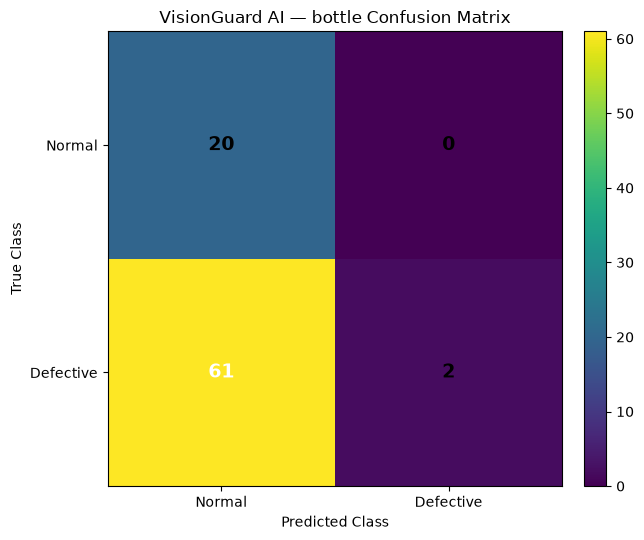

Saved PNG: VisionGuard_AI_capsule_Confusion_Matrix.png


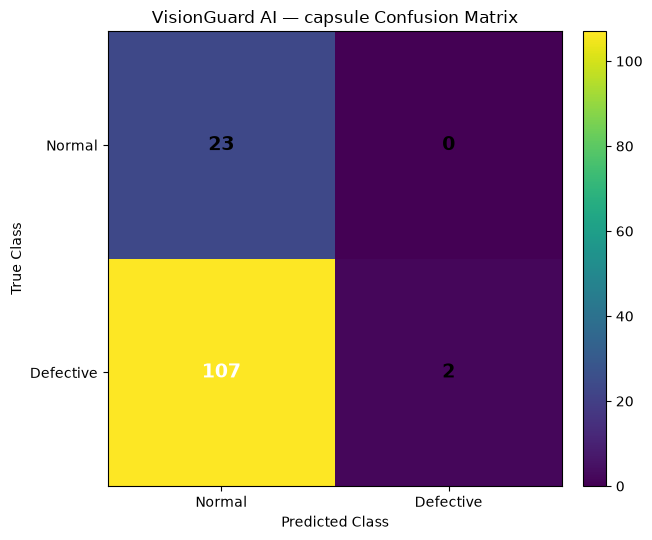

Saved PNG: VisionGuard_AI_hazelnut_Confusion_Matrix.png


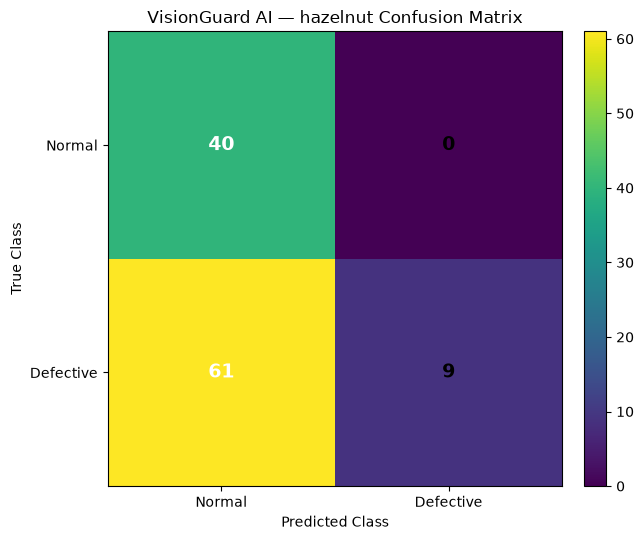

Saved PNG: VisionGuard_AI_metal_nut_Confusion_Matrix.png


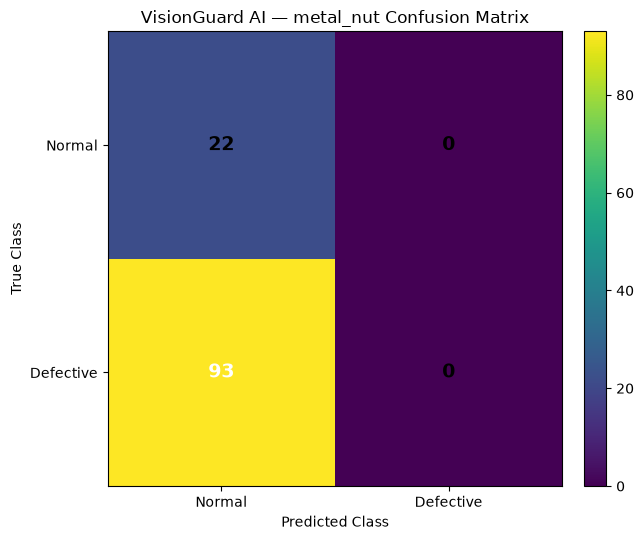

Saved PNG: VisionGuard_AI_screw_Confusion_Matrix.png


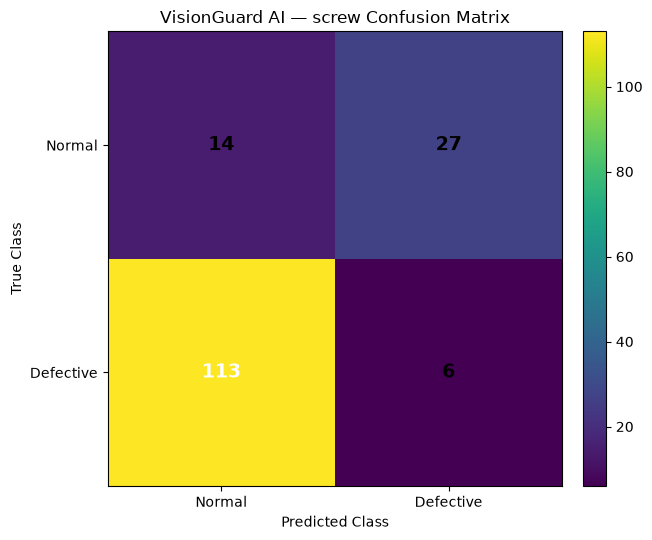

In [53]:
for category in metrics_df["Category"]:
    group = test_results_df[test_results_df["Category"].eq(category)]
    cm = confusion_matrix(group["Label"], group["Predicted Label"], labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"VisionGuard AI — {category} Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.set_xticks([0, 1], ["Normal", "Defective"])
    ax.set_yticks([0, 1], ["Normal", "Defective"])

    threshold = cm.max() / 2.0 if cm.size else 0
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=14,
                fontweight="bold",
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_matplotlib_figure(fig, f"VisionGuard AI — {category} Confusion Matrix")
    plt.show()
    plt.close(fig)

## Section M — ROC analysis

### Build per-category ROC curves

In [54]:
roc_rows = []
for category, group in test_results_df.groupby("Category"):
    y_true = group["Label"].to_numpy()
    scores = group["Reconstruction Error"].to_numpy()
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)
    for fp_rate, tp_rate, threshold in zip(fpr, tpr, thresholds):
        roc_rows.append({
            "Category": category,
            "False Positive Rate": fp_rate,
            "True Positive Rate": tp_rate,
            "Threshold": threshold,
            "ROC-AUC": auc_value,
        })

roc_curve_df = pd.DataFrame(roc_rows)
display(roc_curve_df.head(15).round(6))
export_csv(roc_curve_df, "roc_curve_points.csv")

,Category,False Positive Rate,True Positive Rate,Threshold,ROC-AUC
0,bottle,0.00,0.000000,inf,0.483333
1,bottle,0.00,0.015873,0.108397,0.483333
2,bottle,0.00,0.111111,0.106983,0.483333
3,bottle,0.05,0.111111,0.106861,0.483333
4,bottle,0.05,0.158730,0.106489,0.483333
5,bottle,0.10,0.158730,0.106311,0.483333
6,bottle,0.10,0.190476,0.106215,0.483333
7,bottle,0.15,0.190476,0.106200,0.483333
8,bottle,0.15,0.285714,0.105978,0.483333
9,bottle,0.25,0.285714,0.105965,0.483333


,Category,False Positive Rate,True Positive Rate,Threshold,ROC-AUC
0,bottle,0.00000,0.000000,inf,0.483333
1,bottle,0.00000,0.015873,0.108397,0.483333
2,bottle,0.00000,0.111111,0.106983,0.483333
3,bottle,0.05000,0.111111,0.106861,0.483333
4,bottle,0.05000,0.158730,0.106489,0.483333
...,...,...,...,...,...
162,screw,0.95122,0.176471,0.022553,0.048576
163,screw,0.97561,0.176471,0.022443,0.048576
164,screw,0.97561,0.462185,0.021224,0.048576
165,screw,1.00000,0.462185,0.021222,0.048576


### Plot all category ROC curves

In [55]:
fig = go.Figure()
for category, group in roc_curve_df.groupby("Category"):
    auc_value = float(group["ROC-AUC"].iloc[0])
    fig.add_trace(go.Scatter(
        x=group["False Positive Rate"],
        y=group["True Positive Rate"],
        mode="lines",
        name=f"{category} — AUC {auc_value:.3f}",
    ))
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines", name="Chance",
    line={"dash": "dash"},
))
fig.update_layout(
    title="VisionGuard AI — Category ROC Curves",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis_range=[0, 1],
    yaxis_range=[0, 1],
    template="plotly_white",
)
save_plotly_figure(fig, "VisionGuard AI — Category ROC Curves")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Category_ROC_Curves.html
Plotly PNG export unavailable; interactive HTML was saved.


### Identify a threshold operating point close to the primary threshold

In [56]:
operating_rows = []
for category in roc_curve_df["Category"].unique():
    group = roc_curve_df[roc_curve_df["Category"].eq(category)].copy()
    primary = threshold_map.get(category, np.nan)
    if group.empty or not np.isfinite(primary):
        continue
    idx = (group["Threshold"] - primary).abs().idxmin()
    row = group.loc[idx]
    operating_rows.append({
        "Category": category,
        "Primary Threshold": primary,
        "Closest ROC Threshold": row["Threshold"],
        "False Positive Rate": row["False Positive Rate"],
        "True Positive Rate": row["True Positive Rate"],
    })

operating_point_df = pd.DataFrame(operating_rows)
display(operating_point_df.round(6))
export_csv(operating_point_df, "roc_operating_points.csv")

,Category,Primary Threshold,Closest ROC Threshold,False Positive Rate,True Positive Rate
0,bottle,0.107541,0.106983,0.000000,0.111111
1,capsule,0.066382,0.065742,0.043478,0.018349
2,hazelnut,0.008426,0.006307,0.000000,0.300000
3,metal_nut,0.026352,0.023648,0.045455,0.000000
4,screw,0.024788,0.024714,0.756098,0.050420


,Category,Primary Threshold,Closest ROC Threshold,False Positive Rate,True Positive Rate
0,bottle,0.107541,0.106983,0.000000,0.111111
1,capsule,0.066382,0.065742,0.043478,0.018349
2,hazelnut,0.008426,0.006307,0.000000,0.300000
3,metal_nut,0.026352,0.023648,0.045455,0.000000
4,screw,0.024788,0.024714,0.756098,0.050420


## Section N — Precision–recall analysis

### Build precision–recall curves

In [57]:
pr_rows = []
for category, group in test_results_df.groupby("Category"):
    y_true = group["Label"].to_numpy()
    scores = group["Reconstruction Error"].to_numpy()
    if len(np.unique(y_true)) < 2:
        continue
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    auc_value = average_precision_score(y_true, scores)
    for index in range(len(precision)):
        threshold = thresholds[index] if index < len(thresholds) else np.nan
        pr_rows.append({
            "Category": category,
            "Precision": precision[index],
            "Recall": recall[index],
            "Threshold": threshold,
            "PR-AUC": auc_value,
        })

pr_curve_df = pd.DataFrame(pr_rows)
display(pr_curve_df.head(15).round(6))
export_csv(pr_curve_df, "precision_recall_curve_points.csv")

,Category,Precision,Recall,Threshold,PR-AUC
0,bottle,0.759036,1.000000,0.093258,0.798548
1,bottle,0.756098,0.984127,0.093837,0.798548
2,bottle,0.753086,0.968254,0.098582,0.798548
3,bottle,0.750000,0.952381,0.099636,0.798548
4,bottle,0.746835,0.936508,0.099983,0.798548
5,bottle,0.743590,0.920635,0.101210,0.798548
6,bottle,0.740260,0.904762,0.101383,0.798548
7,bottle,0.736842,0.888889,0.101707,0.798548
8,bottle,0.746667,0.888889,0.102453,0.798548
9,bottle,0.743243,0.873016,0.102681,0.798548


,Category,Precision,Recall,Threshold,PR-AUC
0,bottle,0.759036,1.000000,0.093258,0.798548
1,bottle,0.756098,0.984127,0.093837,0.798548
2,bottle,0.753086,0.968254,0.098582,0.798548
3,bottle,0.750000,0.952381,0.099636,0.798548
4,bottle,0.746835,0.936508,0.099983,0.798548
...,...,...,...,...,...
600,screw,0.000000,0.000000,0.028612,0.542301
601,screw,0.000000,0.000000,0.028655,0.542301
602,screw,0.000000,0.000000,0.029235,0.542301
603,screw,0.000000,0.000000,0.030048,0.542301


### Plot precision–recall curves

In [58]:
fig = go.Figure()
for category, group in pr_curve_df.groupby("Category"):
    auc_value = float(group["PR-AUC"].iloc[0])
    fig.add_trace(go.Scatter(
        x=group["Recall"],
        y=group["Precision"],
        mode="lines",
        name=f"{category} — AP {auc_value:.3f}",
    ))
fig.update_layout(
    title="VisionGuard AI — Category Precision–Recall Curves",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis_range=[0, 1],
    yaxis_range=[0, 1],
    template="plotly_white",
)
save_plotly_figure(fig, "VisionGuard AI — Category Precision Recall Curves")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Category_Precision_Recall_Curves.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section O — Threshold sensitivity analysis

### Evaluate several candidate thresholds on the labeled test set

In [59]:
threshold_sensitivity_rows = []
methods = ["P95", "P99", "Mean + 3Std", "IQR Fence"]

for category, validation_group in validation_errors_df.groupby("Category"):
    candidates = candidate_thresholds(validation_group["Reconstruction Error"].to_numpy())
    test_group = test_results_df[test_results_df["Category"].eq(category)]
    for method in methods:
        threshold = candidates[method]
        y_true = test_group["Label"].to_numpy()
        y_pred = (test_group["Reconstruction Error"].to_numpy() > threshold).astype(int)
        threshold_sensitivity_rows.append({
            "Category": category,
            "Threshold Method": method,
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        })

threshold_sensitivity_df = pd.DataFrame(threshold_sensitivity_rows)
display(threshold_sensitivity_df.round(6))
export_csv(threshold_sensitivity_df, "threshold_sensitivity_comparison.csv")

,Category,Threshold Method,Threshold,Accuracy,Precision,Recall,F1-Score
0,bottle,P95,0.107310,0.265060,1.000000,0.031746,0.061538
1,bottle,P99,0.107541,0.265060,1.000000,0.031746,0.061538
2,bottle,Mean + 3Std,0.110006,0.240964,0.000000,0.000000,0.000000
3,bottle,IQR Fence,0.109120,0.240964,0.000000,0.000000,0.000000
4,capsule,P95,0.066016,0.189394,1.000000,0.018349,0.036036
5,capsule,P99,0.066382,0.189394,1.000000,0.018349,0.036036
6,capsule,Mean + 3Std,0.070081,0.174242,0.000000,0.000000,0.000000
7,capsule,IQR Fence,0.066832,0.189394,1.000000,0.018349,0.036036
8,hazelnut,P95,0.007430,0.463636,1.000000,0.157143,0.271605
9,hazelnut,P99,0.008426,0.445455,1.000000,0.128571,0.227848


,Category,Threshold Method,Threshold,Accuracy,Precision,Recall,F1-Score
0,bottle,P95,0.107310,0.265060,1.000000,0.031746,0.061538
1,bottle,P99,0.107541,0.265060,1.000000,0.031746,0.061538
2,bottle,Mean + 3Std,0.110006,0.240964,0.000000,0.000000,0.000000
3,bottle,IQR Fence,0.109120,0.240964,0.000000,0.000000,0.000000
4,capsule,P95,0.066016,0.189394,1.000000,0.018349,0.036036
5,capsule,P99,0.066382,0.189394,1.000000,0.018349,0.036036
6,capsule,Mean + 3Std,0.070081,0.174242,0.000000,0.000000,0.000000
7,capsule,IQR Fence,0.066832,0.189394,1.000000,0.018349,0.036036
8,hazelnut,P95,0.007430,0.463636,1.000000,0.157143,0.271605
9,hazelnut,P99,0.008426,0.445455,1.000000,0.128571,0.227848


### Plot threshold sensitivity

In [60]:
fig = px.bar(
    threshold_sensitivity_df,
    x="Category",
    y="F1-Score",
    color="Threshold Method",
    barmode="group",
    text_auto=".3f",
    title="VisionGuard AI — F1-Score Sensitivity to Threshold Rule",
    template="plotly_white",
)
fig.update_yaxes(range=[0, 1])
save_plotly_figure(fig, "VisionGuard AI — F1-Score Sensitivity to Threshold Rule")
fig.show()

Saved Plotly HTML: VisionGuard_AI_F1_Score_Sensitivity_to_Threshold_Rule.html
Plotly PNG export unavailable; interactive HTML was saved.


### Quantify how many test decisions change across threshold rules

In [61]:
decision_change_rows = []
for category in test_results_df["Category"].unique():
    validation_group = validation_errors_df[validation_errors_df["Category"].eq(category)]
    candidates = candidate_thresholds(validation_group["Reconstruction Error"].to_numpy())
    group = test_results_df[test_results_df["Category"].eq(category)]
    baseline = (group["Reconstruction Error"].to_numpy() > candidates[PRIMARY_THRESHOLD_METHOD]).astype(int)
    for method, threshold in candidates.items():
        candidate = (group["Reconstruction Error"].to_numpy() > threshold).astype(int)
        decision_change_rows.append({
            "Category": category,
            "Threshold Method": method,
            "Changed Decisions": int(np.sum(candidate != baseline)),
            "Total Images": len(group),
            "Changed Decision Rate": float(np.mean(candidate != baseline)),
        })

decision_change_df = pd.DataFrame(decision_change_rows)
display(decision_change_df.round(6))
export_csv(decision_change_df, "threshold_decision_changes.csv")

,Category,Threshold Method,Changed Decisions,Total Images,Changed Decision Rate
0,screw,P95,3,160,0.018750
1,screw,P99,0,160,0.000000
2,screw,Mean + 3Std,29,160,0.181250
3,screw,IQR Fence,29,160,0.181250
4,bottle,P95,0,83,0.000000
5,bottle,P99,0,83,0.000000
6,bottle,Mean + 3Std,2,83,0.024096
7,bottle,IQR Fence,2,83,0.024096
8,capsule,P95,0,132,0.000000
9,capsule,P99,0,132,0.000000


,Category,Threshold Method,Changed Decisions,Total Images,Changed Decision Rate
0,screw,P95,3,160,0.018750
1,screw,P99,0,160,0.000000
2,screw,Mean + 3Std,29,160,0.181250
3,screw,IQR Fence,29,160,0.181250
4,bottle,P95,0,83,0.000000
5,bottle,P99,0,83,0.000000
6,bottle,Mean + 3Std,2,83,0.024096
7,bottle,IQR Fence,2,83,0.024096
8,capsule,P95,0,132,0.000000
9,capsule,P99,0,132,0.000000


## Section P — False positive and false negative analysis

### Extract false positives and false negatives

In [62]:
false_positive_df = test_results_df[
    (test_results_df["Label"] == 0) &
    (test_results_df["Predicted Label"] == 1)
].copy()

false_negative_df = test_results_df[
    (test_results_df["Label"] == 1) &
    (test_results_df["Predicted Label"] == 0)
].copy()

print("False positives:", len(false_positive_df))
print("False negatives:", len(false_negative_df))

display(false_positive_df.head(20).round(8))
display(false_negative_df.head(20).round(8))

export_csv(false_positive_df, "false_positive_cases.csv")
export_csv(false_negative_df, "false_negative_cases.csv")

False positives: 27
False negatives: 435


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class
0,screw,good,0,000.png,False,0.026038,0.099936,0.681010,0.024788,0.001250,1.050448,1,Defective,Normal
2,screw,good,0,002.png,False,0.025275,0.097502,0.669809,0.024788,0.000488,1.019671,1,Defective,Normal
3,screw,good,0,003.png,False,0.025870,0.102026,0.700419,0.024788,0.001082,1.043659,1,Defective,Normal
5,screw,good,0,005.png,False,0.025288,0.103171,0.697863,0.024788,0.000501,1.020192,1,Defective,Normal
6,screw,good,0,006.png,False,0.025535,0.100564,0.651678,0.024788,0.000747,1.030154,1,Defective,Normal
7,screw,good,0,007.png,False,0.030048,0.107499,0.715271,0.024788,0.005260,1.212198,1,Defective,Normal
8,screw,good,0,008.png,False,0.026949,0.106341,0.649205,0.024788,0.002161,1.087192,1,Defective,Normal
9,screw,good,0,009.png,False,0.025596,0.103532,0.685209,0.024788,0.000808,1.032597,1,Defective,Normal
10,screw,good,0,010.png,False,0.026536,0.105448,0.665819,0.024788,0.001748,1.070510,1,Defective,Normal
11,screw,good,0,011.png,False,0.026332,0.101716,0.670800,0.024788,0.001544,1.062279,1,Defective,Normal


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class
42,screw,manipulated_front,1,001.png,False,0.023738,0.094409,0.706408,0.024788,-0.001050,0.957659,0,Normal,Defective
43,screw,manipulated_front,1,002.png,False,0.024403,0.095692,0.656035,0.024788,-0.000385,0.984486,0,Normal,Defective
44,screw,manipulated_front,1,003.png,False,0.021669,0.090906,0.686335,0.024788,-0.003119,0.874175,0,Normal,Defective
45,screw,manipulated_front,1,004.png,False,0.022602,0.094492,0.683920,0.024788,-0.002186,0.911809,0,Normal,Defective
46,screw,manipulated_front,1,005.png,False,0.021609,0.092182,0.667297,0.024788,-0.003179,0.871741,0,Normal,Defective
47,screw,manipulated_front,1,006.png,False,0.021556,0.091410,0.619762,0.024788,-0.003232,0.869603,0,Normal,Defective
48,screw,manipulated_front,1,007.png,False,0.023032,0.092698,0.668578,0.024788,-0.001755,0.929186,0,Normal,Defective
49,screw,manipulated_front,1,008.png,False,0.020892,0.091833,0.677903,0.024788,-0.003896,0.842819,0,Normal,Defective
50,screw,manipulated_front,1,009.png,False,0.021368,0.089778,0.706726,0.024788,-0.003420,0.862019,0,Normal,Defective
51,screw,manipulated_front,1,010.png,False,0.022554,0.096012,0.644116,0.024788,-0.002233,0.909900,0,Normal,Defective


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class
42,screw,manipulated_front,1,001.png,False,0.023738,0.094409,0.706408,0.024788,-0.001050,0.957659,0,Normal,Defective
43,screw,manipulated_front,1,002.png,False,0.024403,0.095692,0.656035,0.024788,-0.000385,0.984486,0,Normal,Defective
44,screw,manipulated_front,1,003.png,False,0.021669,0.090906,0.686335,0.024788,-0.003119,0.874175,0,Normal,Defective
45,screw,manipulated_front,1,004.png,False,0.022602,0.094492,0.683920,0.024788,-0.002186,0.911809,0,Normal,Defective
46,screw,manipulated_front,1,005.png,False,0.021609,0.092182,0.667297,0.024788,-0.003179,0.871741,0,Normal,Defective
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,hazelnut,print,1,009.png,False,0.006504,0.060361,0.764329,0.008426,-0.001922,0.771846,0,Normal,Defective
595,hazelnut,print,1,012.png,False,0.006952,0.058714,0.767989,0.008426,-0.001474,0.825076,0,Normal,Defective
596,hazelnut,print,1,013.png,False,0.005922,0.059496,0.718265,0.008426,-0.002505,0.702764,0,Normal,Defective
597,hazelnut,print,1,014.png,False,0.007092,0.060288,0.743212,0.008426,-0.001334,0.841695,0,Normal,Defective


### Summarize false positives by category

In [63]:
fp_summary_df = (
    false_positive_df
    .groupby("Category", as_index=False)
    .agg(
        False_Positives=("Category", "size"),
        Mean_Score=("Reconstruction Error", "mean"),
        Maximum_Score=("Reconstruction Error", "max"),
    )
    .rename(columns={
        "False_Positives": "False Positives",
        "Mean_Score": "Mean Score",
        "Maximum_Score": "Maximum Score",
    })
)
display(fp_summary_df.round(8))
export_csv(fp_summary_df, "false_positive_summary.csv")

,Category,False Positives,Mean Score,Maximum Score
0,screw,27,0.026554,0.030048


,Category,False Positives,Mean Score,Maximum Score
0,screw,27,0.026554,0.030048


### Summarize false negatives by category and defect type

In [64]:
fn_summary_df = (
    false_negative_df
    .groupby(["Category", "Defect Type"], as_index=False)
    .agg(
        False_Negatives=("Category", "size"),
        Mean_Score=("Reconstruction Error", "mean"),
        Maximum_Score=("Reconstruction Error", "max"),
    )
    .rename(columns={
        "False_Negatives": "False Negatives",
        "Mean_Score": "Mean Score",
        "Maximum_Score": "Maximum Score",
    })
)
display(fn_summary_df.round(8))
export_csv(fn_summary_df, "false_negative_summary.csv")

,Category,Defect Type,False Negatives,Mean Score,Maximum Score
0,bottle,broken_large,18,0.104599,0.107077
1,bottle,broken_small,22,0.105663,0.107256
2,bottle,contamination,21,0.102711,0.107225
3,capsule,crack,23,0.061183,0.065354
4,capsule,faulty_imprint,22,0.059164,0.063419
5,capsule,poke,21,0.060234,0.063480
6,capsule,scratch,23,0.059215,0.062808
7,capsule,squeeze,18,0.058405,0.064925
8,hazelnut,crack,16,0.005142,0.008316
9,hazelnut,cut,17,0.004394,0.005613


,Category,Defect Type,False Negatives,Mean Score,Maximum Score
0,bottle,broken_large,18,0.104599,0.107077
1,bottle,broken_small,22,0.105663,0.107256
2,bottle,contamination,21,0.102711,0.107225
3,capsule,crack,23,0.061183,0.065354
4,capsule,faulty_imprint,22,0.059164,0.063419
5,capsule,poke,21,0.060234,0.063480
6,capsule,scratch,23,0.059215,0.062808
7,capsule,squeeze,18,0.058405,0.064925
8,hazelnut,crack,16,0.005142,0.008316
9,hazelnut,cut,17,0.004394,0.005613


### Plot error counts

In [65]:
error_count_rows = []
for category in CATEGORIES:
    group = test_results_df[test_results_df["Category"].eq(category)]
    if group.empty:
        continue
    error_count_rows.extend([
        {"Category": category, "Error Type": "False Positive", "Count": int(((group["Label"] == 0) & (group["Predicted Label"] == 1)).sum())},
        {"Category": category, "Error Type": "False Negative", "Count": int(((group["Label"] == 1) & (group["Predicted Label"] == 0)).sum())},
    ])

error_count_df = pd.DataFrame(error_count_rows)
display(error_count_df)
export_csv(error_count_df, "classification_error_counts.csv")

fig = px.bar(
    error_count_df,
    x="Category",
    y="Count",
    color="Error Type",
    barmode="group",
    text="Count",
    title="VisionGuard AI — False Positive and False Negative Counts",
    template="plotly_white",
)
fig.update_traces(textposition="outside")
save_plotly_figure(fig, "VisionGuard AI — False Positive and False Negative Counts")
fig.show()

,Category,Error Type,Count
0,screw,False Positive,27
1,screw,False Negative,113
2,bottle,False Positive,0
3,bottle,False Negative,61
4,capsule,False Positive,0
5,capsule,False Negative,107
6,metal_nut,False Positive,0
7,metal_nut,False Negative,93
8,hazelnut,False Positive,0
9,hazelnut,False Negative,61


Saved Plotly HTML: VisionGuard_AI_False_Positive_and_False_Negative_Counts.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section Q — Detailed qualitative visual inspection

### Select representative normal, defective, false-positive and false-negative examples

In [66]:
def select_case(group, sort_column, ascending, count=1):
    if group.empty:
        return group
    return group.sort_values(sort_column, ascending=ascending).head(count)

representative_cases = {}
for category in test_results_df["Category"].unique():
    group = test_results_df[test_results_df["Category"].eq(category)]
    representative_cases[category] = {
        "normal_low": select_case(group[group["Label"] == 0], "Reconstruction Error", True),
        "normal_high": select_case(group[group["Label"] == 0], "Reconstruction Error", False),
        "defective_low": select_case(group[group["Label"] == 1], "Reconstruction Error", True),
        "defective_high": select_case(group[group["Label"] == 1], "Reconstruction Error", False),
        "false_positive": group[(group["Label"] == 0) & (group["Predicted Label"] == 1)].head(1),
        "false_negative": group[(group["Label"] == 1) & (group["Predicted Label"] == 0)].head(1),
    }

print("Representative cases selected for each available category.")

Representative cases selected for each available category.


### Build a compact representative-case report

In [67]:
case_rows = []
for category, cases in representative_cases.items():
    for case_name, frame in cases.items():
        if frame.empty:
            continue
        row = frame.iloc[0]
        case_rows.append({
            "Category": category,
            "Case": case_name,
            "File": row["File"],
            "Defect Type": row["Defect Type"],
            "True Class": row["True Class"],
            "Prediction": row["Prediction"],
            "Reconstruction Error": row["Reconstruction Error"],
            "Threshold": row["Threshold"],
            "Normalized Anomaly Score": row["Normalized Anomaly Score"],
        })

representative_case_df = pd.DataFrame(case_rows)
display(representative_case_df.round(8))
export_csv(representative_case_df, "representative_cases.csv")

,Category,Case,File,Defect Type,True Class,Prediction,Reconstruction Error,Threshold,Normalized Anomaly Score
0,screw,normal_low,034.png,good,Normal,Normal,0.021222,0.024788,0.856137
1,screw,normal_high,007.png,good,Normal,Defective,0.030048,0.024788,1.212198
2,screw,defective_low,015.png,thread_top,Defective,Normal,0.017445,0.024788,0.703763
3,screw,defective_high,020.png,manipulated_front,Defective,Defective,0.027445,0.024788,1.107182
4,screw,false_positive,000.png,good,Normal,Defective,0.026038,0.024788,1.050448
5,screw,false_negative,001.png,manipulated_front,Defective,Normal,0.023738,0.024788,0.957659
6,bottle,normal_low,013.png,good,Normal,Normal,0.101707,0.107541,0.945747
7,bottle,normal_high,009.png,good,Normal,Normal,0.106861,0.107541,0.993672
8,bottle,defective_low,012.png,contamination,Defective,Normal,0.093258,0.107541,0.867179
9,bottle,defective_high,003.png,broken_large,Defective,Defective,0.108397,0.107541,1.007955


,Category,Case,File,Defect Type,True Class,Prediction,Reconstruction Error,Threshold,Normalized Anomaly Score
0,screw,normal_low,034.png,good,Normal,Normal,0.021222,0.024788,0.856137
1,screw,normal_high,007.png,good,Normal,Defective,0.030048,0.024788,1.212198
2,screw,defective_low,015.png,thread_top,Defective,Normal,0.017445,0.024788,0.703763
3,screw,defective_high,020.png,manipulated_front,Defective,Defective,0.027445,0.024788,1.107182
4,screw,false_positive,000.png,good,Normal,Defective,0.026038,0.024788,1.050448
5,screw,false_negative,001.png,manipulated_front,Defective,Normal,0.023738,0.024788,0.957659
6,bottle,normal_low,013.png,good,Normal,Normal,0.101707,0.107541,0.945747
7,bottle,normal_high,009.png,good,Normal,Normal,0.106861,0.107541,0.993672
8,bottle,defective_low,012.png,contamination,Defective,Normal,0.093258,0.107541,0.867179
9,bottle,defective_high,003.png,broken_large,Defective,Defective,0.108397,0.107541,1.007955


### Visualize normal and defective examples

In [68]:
def plot_prediction_gallery(category, selections, title):
    valid = [frame.iloc[0] for frame in selections if not frame.empty]
    if not valid:
        return

    fig, axes = plt.subplots(1, len(valid), figsize=(5 * len(valid), 5))
    axes = np.atleast_1d(axes)

    for ax, row in zip(axes, valid):
        match = test_manifest_df[
            (test_manifest_df["Category"] == category) &
            (test_manifest_df["File"] == row["File"]) &
            (test_manifest_df["Defect Type"] == row["Defect Type"])
        ]
        if match.empty:
            ax.text(0.5, 0.5, "Image unavailable", ha="center", va="center")
            ax.axis("off")
            continue

        image = load_rgb_array(match.iloc[0]["_image_path"])
        ax.imshow(image)
        ax.set_title(
            f"{row['True Class']} | {row['Prediction']}\n"
            f"Error={row['Reconstruction Error']:.6f}\n"
            f"Score={row['Normalized Anomaly Score']:.2f}",
            fontsize=10,
        )
        ax.axis("off")

    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    save_matplotlib_figure(fig, title)
    plt.show()
    plt.close(fig)

print("Prediction gallery helper ready.")

Prediction gallery helper ready.


### Visualize false positives and false negatives when available

Saved PNG: VisionGuard_AI_screw_Classification_Errors.png


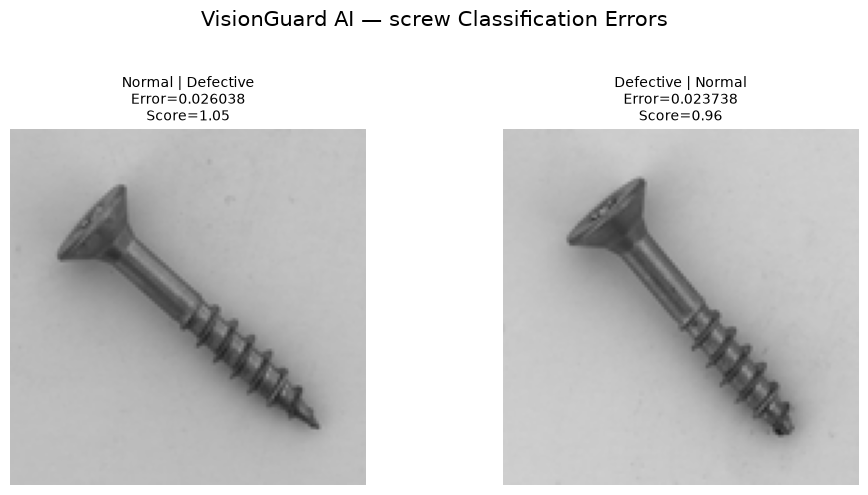

Saved PNG: VisionGuard_AI_bottle_Classification_Errors.png


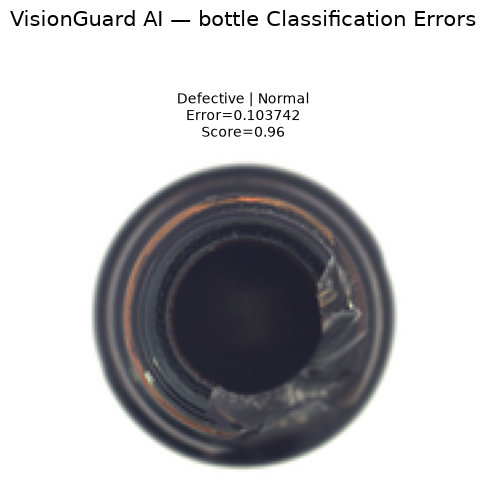

Saved PNG: VisionGuard_AI_capsule_Classification_Errors.png


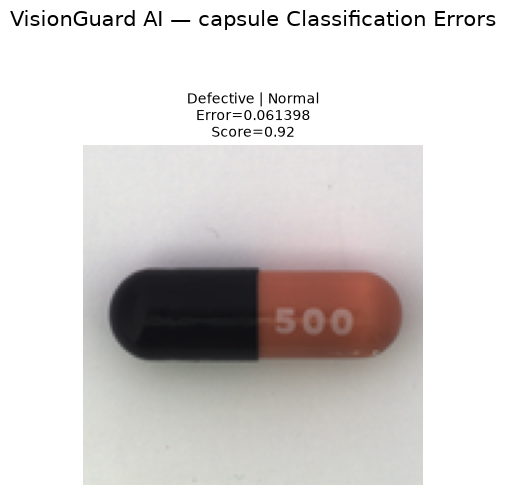

Saved PNG: VisionGuard_AI_metal_nut_Classification_Errors.png


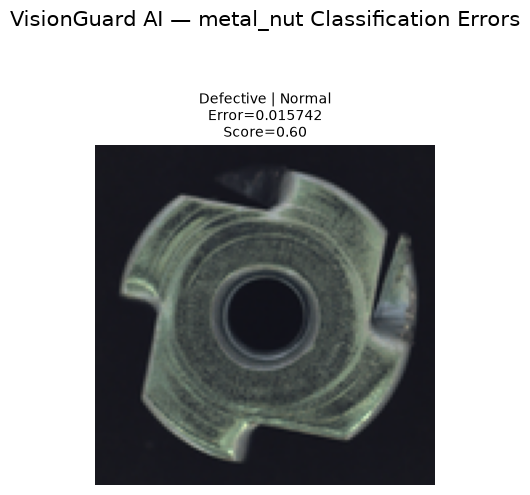

Saved PNG: VisionGuard_AI_hazelnut_Classification_Errors.png


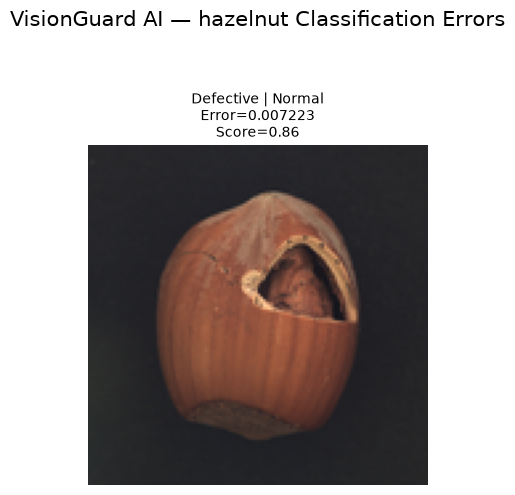

In [69]:
for category, cases in representative_cases.items():
    selected = [cases["false_positive"], cases["false_negative"]]
    if all(frame.empty for frame in selected):
        continue
    plot_prediction_gallery(
        category,
        selected,
        f"VisionGuard AI — {category} Classification Errors",
    )

## Section R — Original versus reconstruction versus error map

### Create reconstruction comparison for one sample

In [70]:
def plot_reconstruction_comparison(category, record):
    manifest_match = test_manifest_df[
        (test_manifest_df["Category"] == category) &
        (test_manifest_df["File"] == record["File"])
    ]
    if manifest_match.empty:
        return

    image_path = manifest_match.iloc[0]["_image_path"]
    model = best_models[category]
    image, reconstruction, scores = predict_single(model, image_path)
    threshold = threshold_map[category]

    error_map = scores["error_map_mae"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[1].imshow(reconstruction)
    axes[1].set_title("Reconstruction")
    im = axes[2].imshow(error_map, cmap="magma")
    axes[2].set_title(f"Absolute Error Map\nMSE={scores['mse']:.6f} | Threshold={threshold:.6f}")

    for ax in axes:
        ax.axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    title = f"VisionGuard AI — {category} Original Reconstruction Error Map"
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    save_matplotlib_figure(fig, title)
    plt.show()
    plt.close(fig)

print("Reconstruction visualization helper ready.")

Reconstruction visualization helper ready.


### Visualize one normal and one defective reconstruction per category

2026-10-02 16:43:05.046780: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Saved PNG: VisionGuard_AI_screw_Original_Reconstruction_Error_Map.png


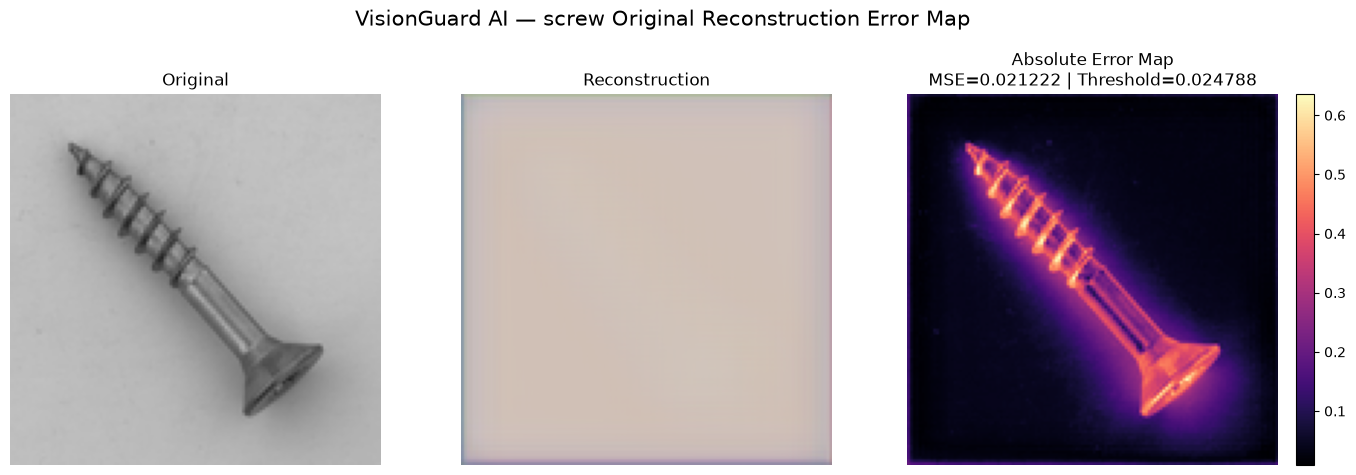

Saved PNG: VisionGuard_AI_screw_Original_Reconstruction_Error_Map.png


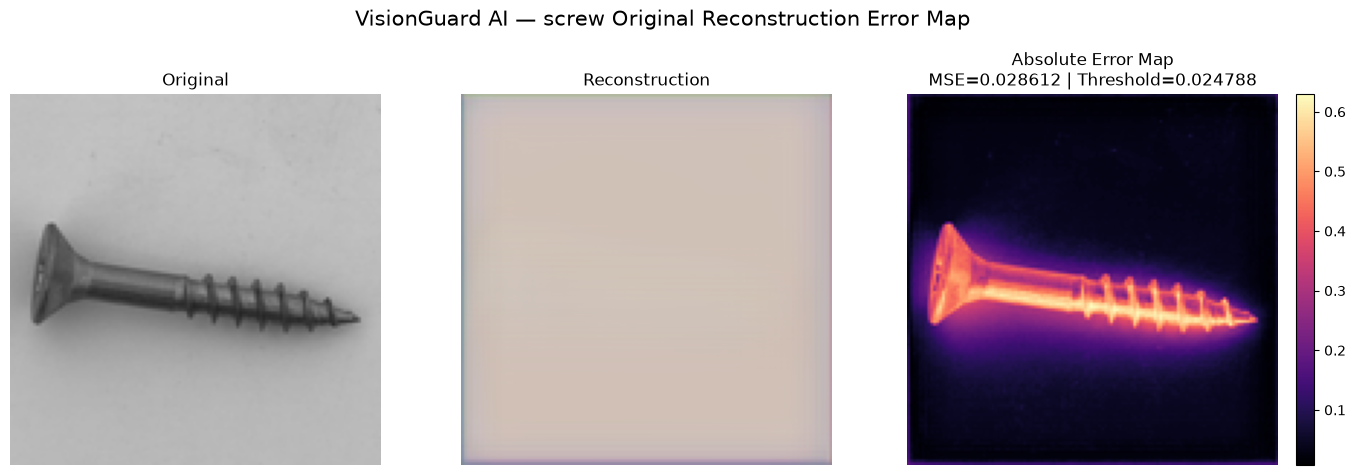

Saved PNG: VisionGuard_AI_bottle_Original_Reconstruction_Error_Map.png


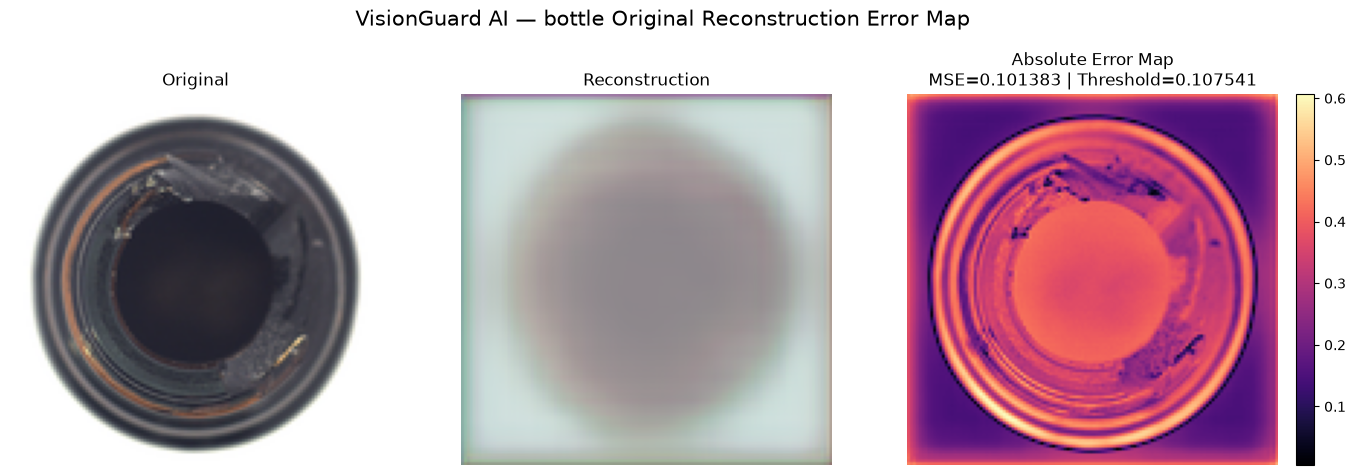

Saved PNG: VisionGuard_AI_bottle_Original_Reconstruction_Error_Map.png


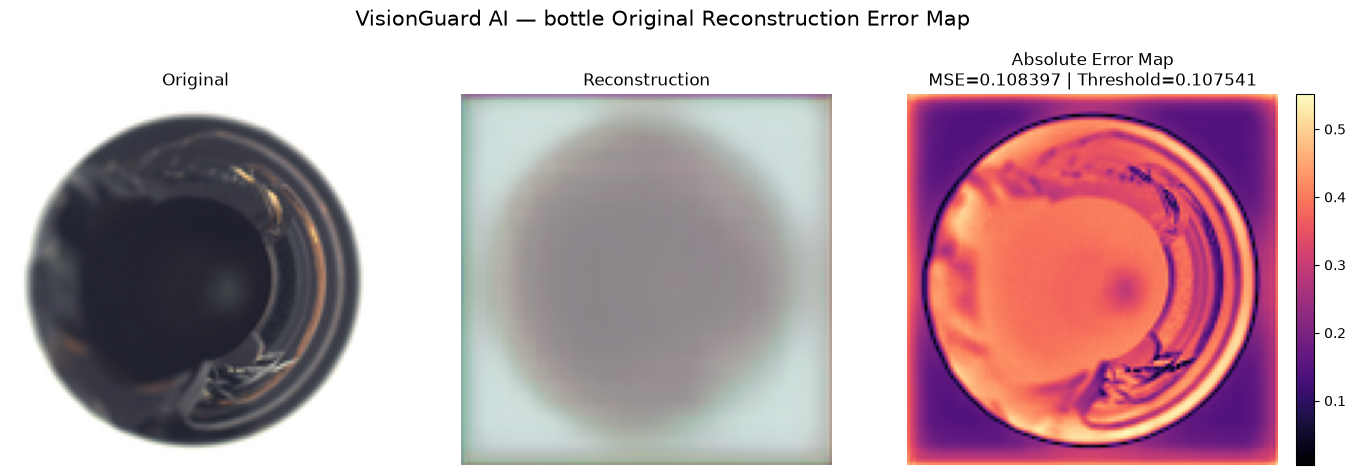

Saved PNG: VisionGuard_AI_capsule_Original_Reconstruction_Error_Map.png


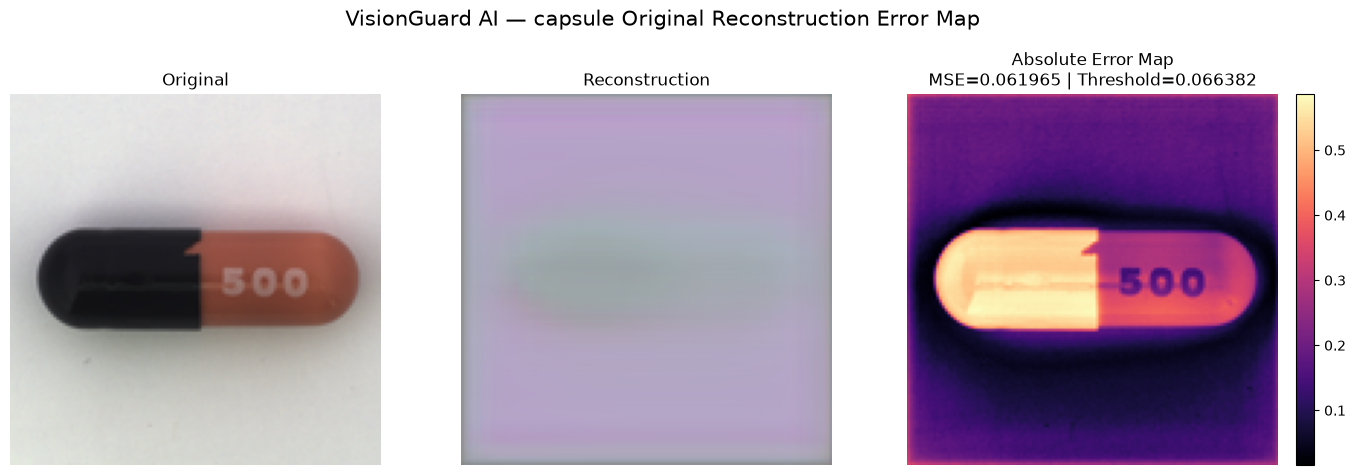

Saved PNG: VisionGuard_AI_capsule_Original_Reconstruction_Error_Map.png


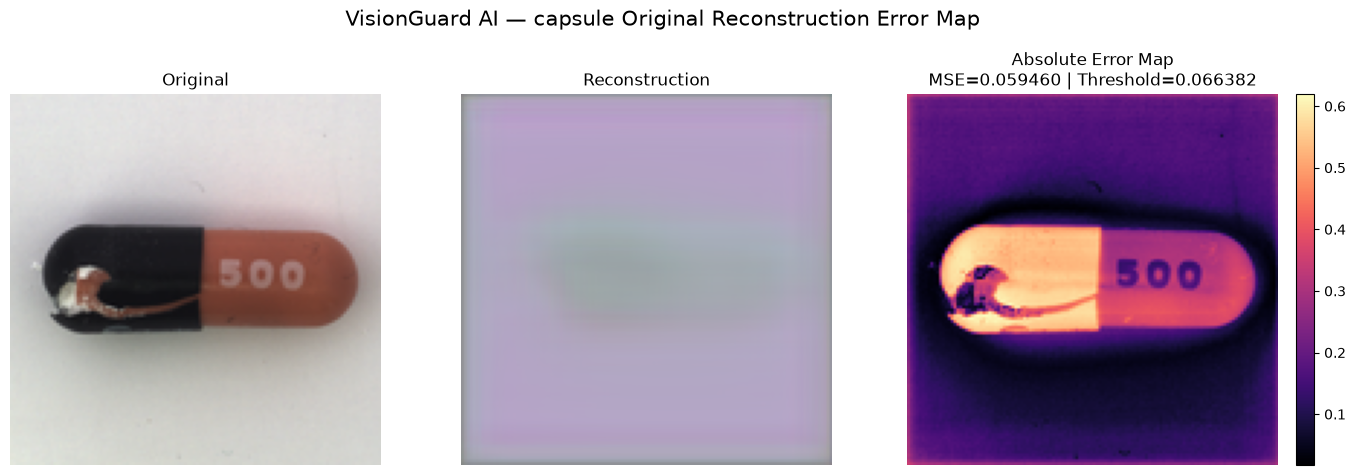

Saved PNG: VisionGuard_AI_metal_nut_Original_Reconstruction_Error_Map.png


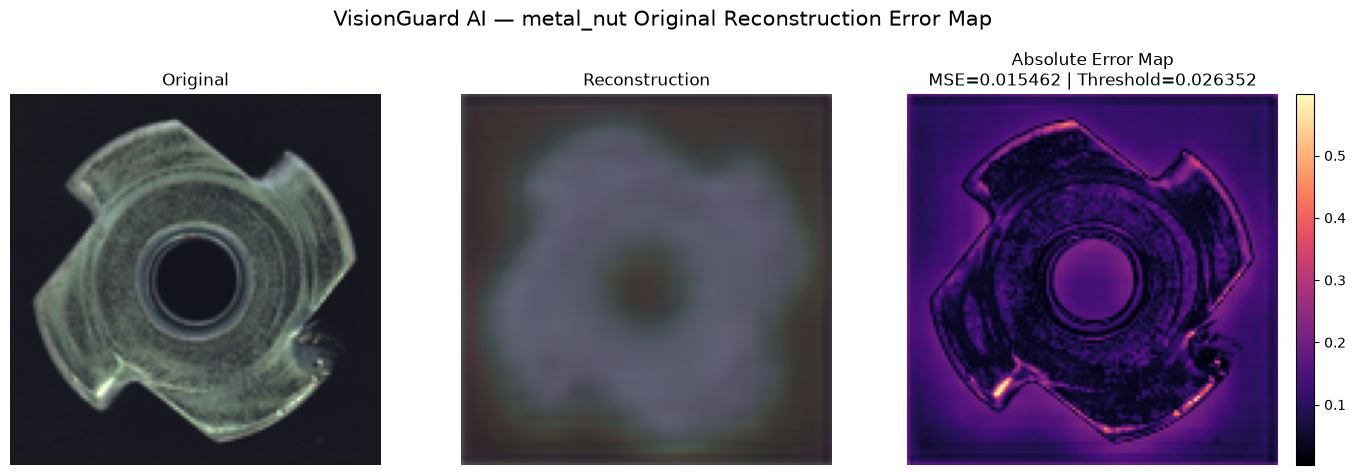

2026-10-02 16:43:10.754430: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Saved PNG: VisionGuard_AI_metal_nut_Original_Reconstruction_Error_Map.png


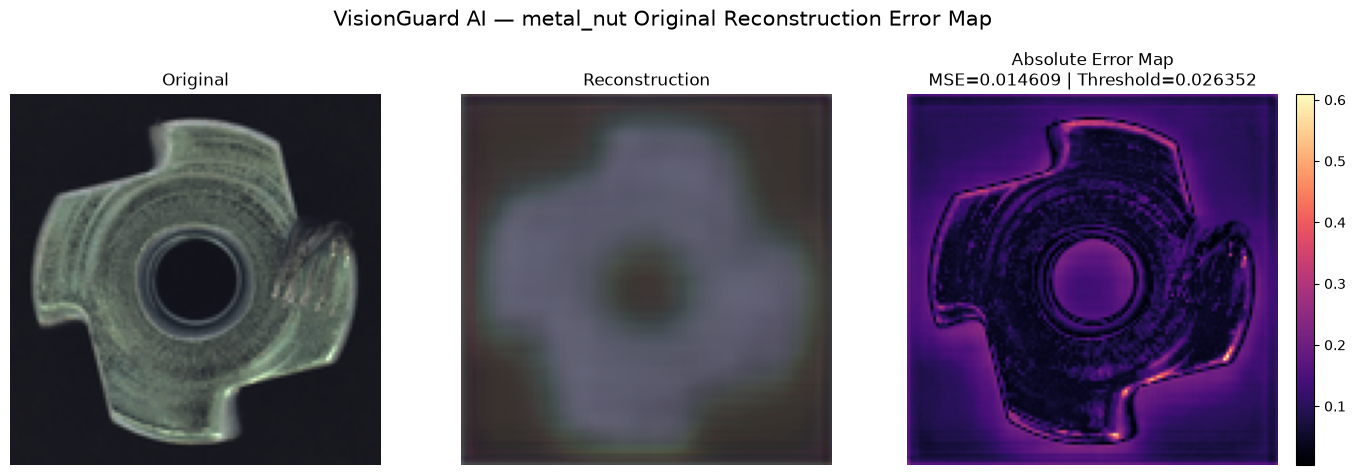

Saved PNG: VisionGuard_AI_hazelnut_Original_Reconstruction_Error_Map.png


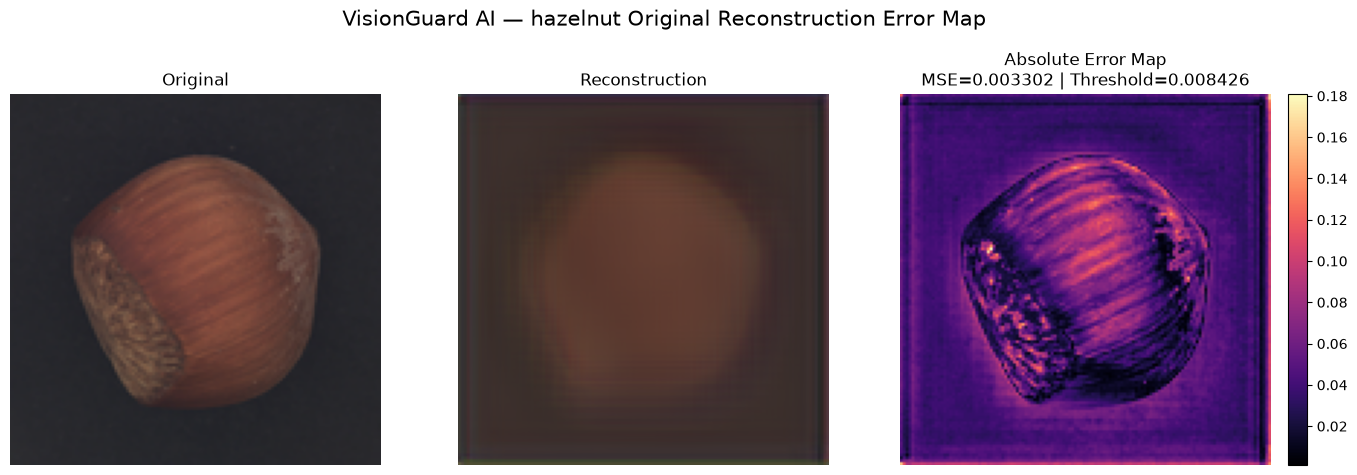

Saved PNG: VisionGuard_AI_hazelnut_Original_Reconstruction_Error_Map.png


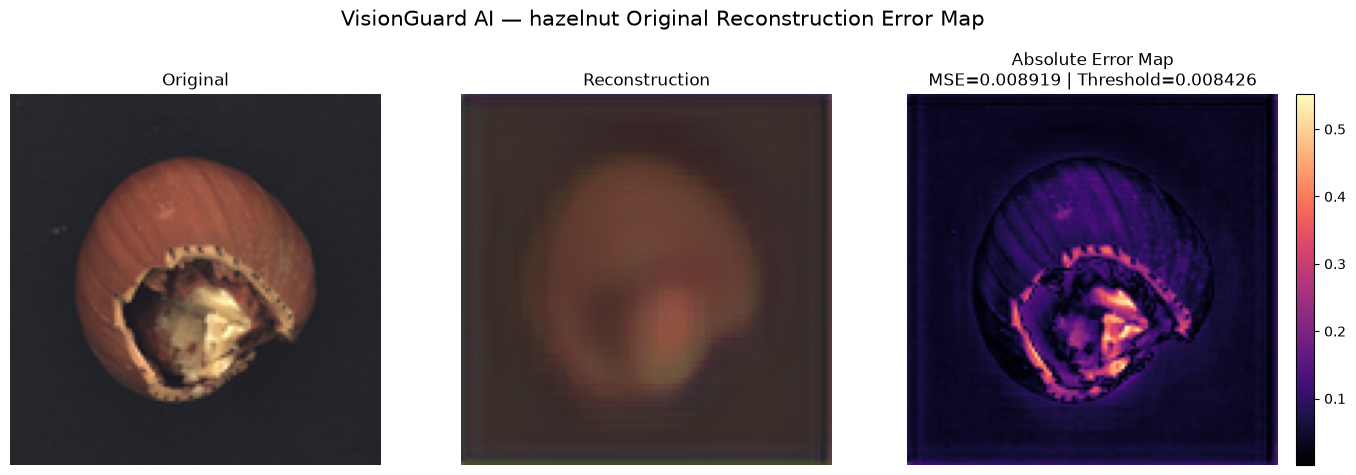

In [71]:
for category in best_models:
    group = test_results_df[test_results_df["Category"].eq(category)]
    normal = group[group["Label"] == 0].sort_values("Reconstruction Error").head(1)
    defective = group[group["Label"] == 1].sort_values("Reconstruction Error", ascending=False).head(1)
    for frame in [normal, defective]:
        if not frame.empty:
            plot_reconstruction_comparison(category, frame.iloc[0])

## Section S — Ground-truth mask alignment check

### Visualize a defective image alongside its matched ground-truth mask

In [72]:
def plot_ground_truth_alignment(category, record):
    manifest_match = test_manifest_df[
        (test_manifest_df["Category"] == category) &
        (test_manifest_df["File"] == record["File"]) &
        (test_manifest_df["Defect Type"] == record["Defect Type"])
    ]
    if manifest_match.empty:
        return

    row = manifest_match.iloc[0]
    if row["_gt_path"] is None:
        print(f"{category} — {record['File']}: ground-truth mask unavailable")
        return

    image = load_rgb_array(row["_image_path"])
    mask = load_mask_array(row["_gt_path"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].imshow(image)
    axes[0].set_title(f"{category} — {record['Defect Type']}")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Ground-Truth Mask")
    for ax in axes:
        ax.axis("off")

    title = f"VisionGuard AI — {category} Ground Truth Alignment"
    fig.suptitle(title, fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    save_matplotlib_figure(fig, title)
    plt.show()
    plt.close(fig)

for category in best_models:
    defective = test_results_df[
        (test_results_df["Category"] == category) &
        (test_results_df["Label"] == 1) &
        (test_results_df["Ground Truth Available"])
    ].head(1)
    if not defective.empty:
        plot_ground_truth_alignment(category, defective.iloc[0])


## Section T — Detection threshold visualization

### Show threshold position against the score distribution

Saved PNG: VisionGuard_AI_screw_Reconstruction_Error_and_Threshold.png


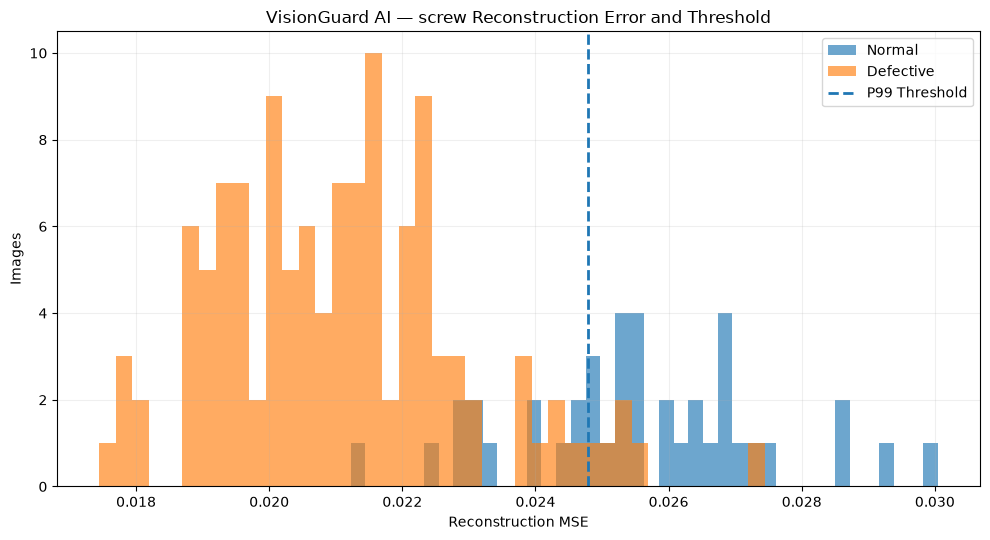

Saved PNG: VisionGuard_AI_bottle_Reconstruction_Error_and_Threshold.png


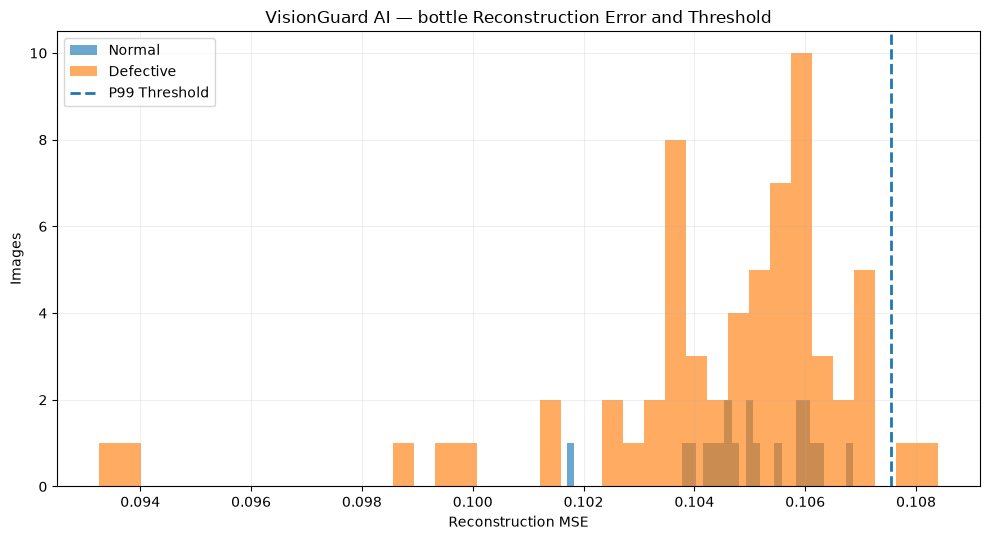

Saved PNG: VisionGuard_AI_capsule_Reconstruction_Error_and_Threshold.png


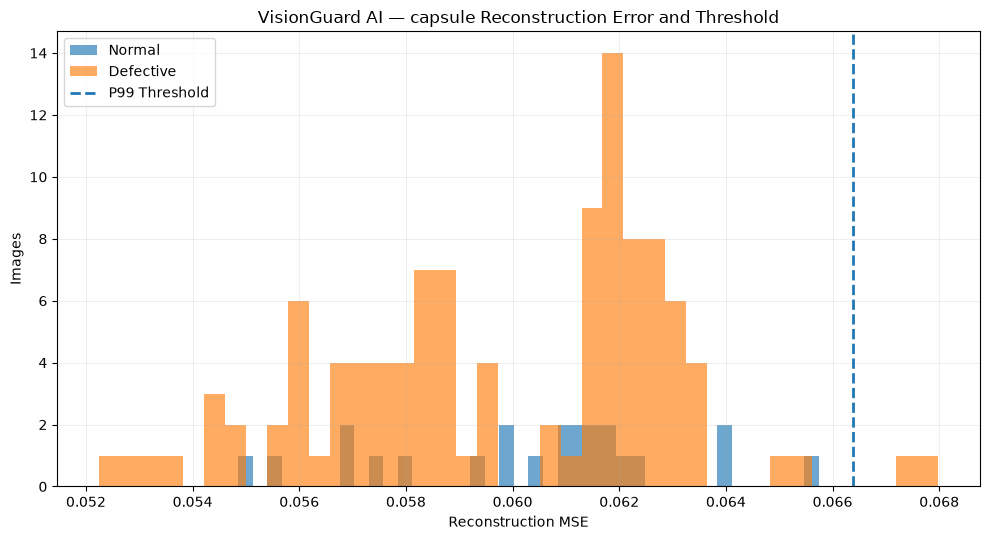

Saved PNG: VisionGuard_AI_metal_nut_Reconstruction_Error_and_Threshold.png


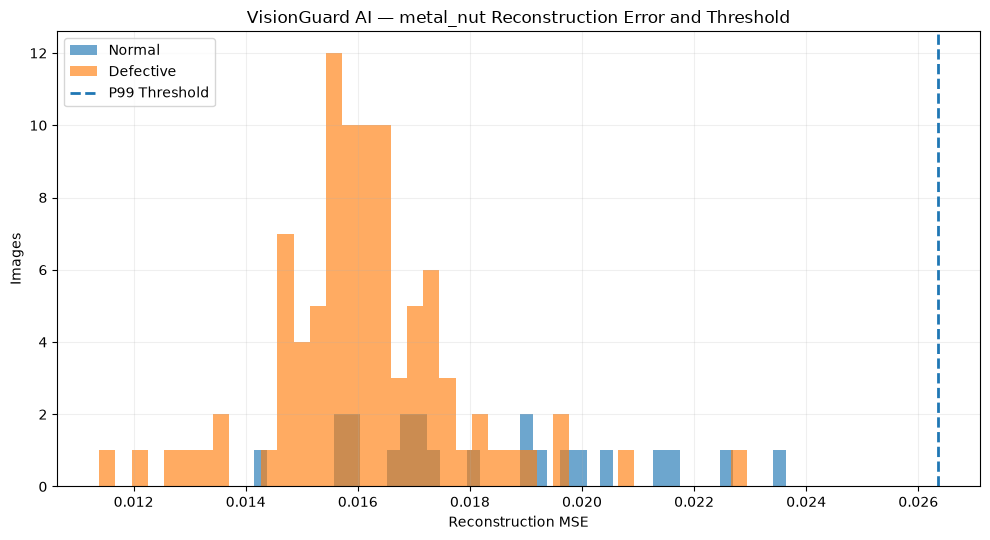

Saved PNG: VisionGuard_AI_hazelnut_Reconstruction_Error_and_Threshold.png


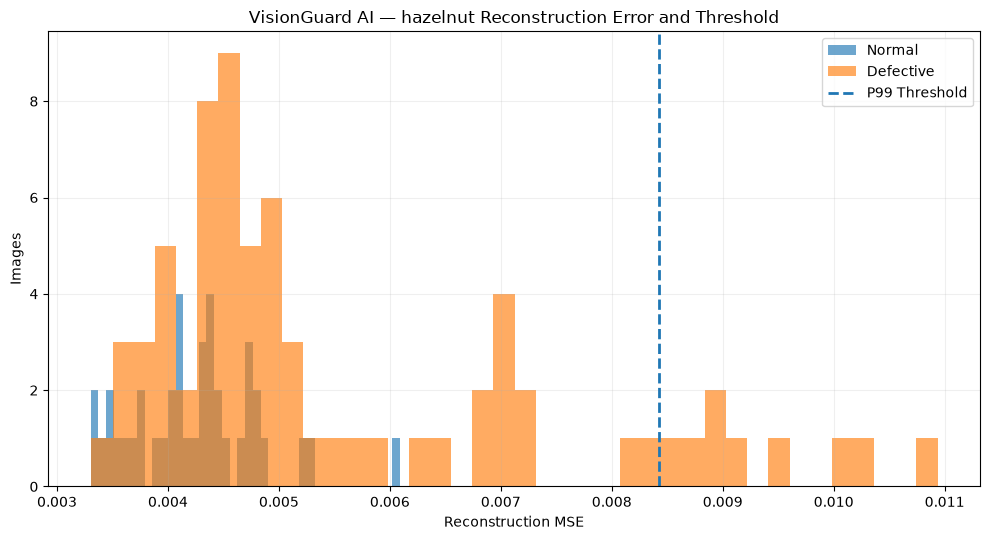

In [73]:
for category in test_results_df["Category"].unique():
    group = test_results_df[test_results_df["Category"].eq(category)]
    threshold = threshold_map[category]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.hist(
        group.loc[group["Label"] == 0, "Reconstruction Error"],
        bins=40,
        alpha=0.65,
        label="Normal",
    )
    ax.hist(
        group.loc[group["Label"] == 1, "Reconstruction Error"],
        bins=40,
        alpha=0.65,
        label="Defective",
    )
    ax.axvline(threshold, linestyle="--", linewidth=2, label="P99 Threshold")
    ax.set_title(f"VisionGuard AI — {category} Reconstruction Error and Threshold")
    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Images")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    save_matplotlib_figure(fig, f"VisionGuard AI — {category} Reconstruction Error and Threshold")
    plt.show()
    plt.close(fig)

## Section U — Cross-category normalized anomaly analysis

Raw reconstruction MSE values are model-specific. To create a pooled diagnostic view, this notebook divides each test score by its category-specific threshold. A value near `1.0` lies near the decision boundary; values above `1.0` are increasingly anomalous relative to that category's calibrated threshold.

In [74]:
pooled_y = test_results_df["Label"].to_numpy()
pooled_scores = test_results_df["Normalized Anomaly Score"].to_numpy()

pooled_roc_auc = safe_roc_auc(pooled_y, pooled_scores)
pooled_pr_auc = safe_pr_auc(pooled_y, pooled_scores)

pooled_summary_df = pd.DataFrame([{
    "Images": len(test_results_df),
    "Normal Images": int((pooled_y == 0).sum()),
    "Defective Images": int((pooled_y == 1).sum()),
    "Normalized ROC-AUC": pooled_roc_auc,
    "Normalized PR-AUC": pooled_pr_auc,
}])

display(pooled_summary_df.round(6))
export_csv(pooled_summary_df, "normalized_pooled_metrics.csv")

,Images,Normal Images,Defective Images,Normalized ROC-AUC,Normalized PR-AUC
0,600,146,454,0.4513,0.694113


,Images,Normal Images,Defective Images,Normalized ROC-AUC,Normalized PR-AUC
0,600,146,454,0.4513,0.694113


### Plot normalized pooled ROC curve

In [75]:
if len(np.unique(pooled_y)) == 2:
    fpr, tpr, _ = roc_curve(pooled_y, pooled_scores)
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"Normalized ROC — AUC {pooled_roc_auc:.3f}"))
    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Chance", line={"dash": "dash"}))
    fig.update_layout(
        title="VisionGuard AI — Normalized Pooled ROC Curve",
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate",
        xaxis_range=[0, 1],
        yaxis_range=[0, 1],
        template="plotly_white",
    )
    save_plotly_figure(fig, "VisionGuard AI — Normalized Pooled ROC Curve")
    fig.show()
else:
    print("Pooled ROC curve requires both normal and defective labels.")

Saved Plotly HTML: VisionGuard_AI_Normalized_Pooled_ROC_Curve.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section V — Confidence-style score bands

### Assign interpretable score bands

In [76]:
def score_band(normalized_score):
    if not np.isfinite(normalized_score):
        return "Unavailable"
    if normalized_score < 0.75:
        return "Low"
    if normalized_score < 1.0:
        return "Borderline Normal"
    if normalized_score < 1.5:
        return "Borderline Anomaly"
    if normalized_score < 2.5:
        return "Moderate Anomaly"
    return "High Anomaly"


test_results_df["Score Band"] = test_results_df["Normalized Anomaly Score"].map(score_band)
score_band_df = (
    test_results_df
    .groupby(["Category", "Score Band"], as_index=False)
    .size()
    .rename(columns={"size": "Images"})
)
display(score_band_df)
export_csv(score_band_df, "score_band_distribution.csv")

,Category,Score Band,Images
0,bottle,Borderline Anomaly,2
1,bottle,Borderline Normal,81
2,capsule,Borderline Anomaly,2
3,capsule,Borderline Normal,130
4,hazelnut,Borderline Anomaly,9
5,hazelnut,Borderline Normal,11
6,hazelnut,Low,90
7,metal_nut,Borderline Normal,8
8,metal_nut,Low,107
9,screw,Borderline Anomaly,33


,Category,Score Band,Images
0,bottle,Borderline Anomaly,2
1,bottle,Borderline Normal,81
2,capsule,Borderline Anomaly,2
3,capsule,Borderline Normal,130
4,hazelnut,Borderline Anomaly,9
5,hazelnut,Borderline Normal,11
6,hazelnut,Low,90
7,metal_nut,Borderline Normal,8
8,metal_nut,Low,107
9,screw,Borderline Anomaly,33


### Plot score bands

In [77]:
fig = px.bar(
    score_band_df,
    x="Category",
    y="Images",
    color="Score Band",
    barmode="stack",
    title="VisionGuard AI — Normalized Anomaly Score Bands",
    text="Images",
    template="plotly_white",
)
fig.update_traces(textposition="inside")
save_plotly_figure(fig, "VisionGuard AI — Normalized Anomaly Score Bands")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Normalized_Anomaly_Score_Bands.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section W — Worst-case and best-case examples

### Identify high-score normal images and low-score defective images

In [78]:
hard_normal_df = (
    test_results_df[test_results_df["Label"] == 0]
    .sort_values(["Category", "Reconstruction Error"], ascending=[True, False])
    .groupby("Category", as_index=False)
    .head(5)
)

hard_defective_df = (
    test_results_df[test_results_df["Label"] == 1]
    .sort_values(["Category", "Reconstruction Error"], ascending=[True, True])
    .groupby("Category", as_index=False)
    .head(5)
)

print("Highest-scoring normal examples:")
display(hard_normal_df.round(8))
print("Lowest-scoring defective examples:")
display(hard_defective_df.round(8))

export_csv(hard_normal_df, "highest_scoring_normal_examples.csv")
export_csv(hard_defective_df, "lowest_scoring_defective_examples.csv")

Highest-scoring normal examples:


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class,Score Band
232,bottle,good,0,009.png,False,0.106861,0.307609,0.660378,0.107541,-0.000681,0.993672,0,Normal,Normal,Borderline Normal
231,bottle,good,0,008.png,False,0.106311,0.306132,0.679928,0.107541,-0.001230,0.988559,0,Normal,Normal,Borderline Normal
227,bottle,good,0,004.png,False,0.106200,0.306464,0.670029,0.107541,-0.001342,0.987523,0,Normal,Normal,Borderline Normal
241,bottle,good,0,018.png,False,0.105974,0.306916,0.654427,0.107541,-0.001567,0.985430,0,Normal,Normal,Borderline Normal
224,bottle,good,0,001.png,False,0.105965,0.306090,0.675173,0.107541,-0.001576,0.985346,0,Normal,Normal,Borderline Normal
295,capsule,good,0,007.png,False,0.065742,0.207081,0.623725,0.066382,-0.000640,0.990355,0,Normal,Normal,Borderline Normal
294,capsule,good,0,006.png,False,0.064029,0.202038,0.619850,0.066382,-0.002353,0.964549,0,Normal,Normal,Borderline Normal
293,capsule,good,0,005.png,False,0.063989,0.199760,0.604472,0.066382,-0.002393,0.963949,0,Normal,Normal,Borderline Normal
303,capsule,good,0,015.png,False,0.062207,0.190304,0.623016,0.066382,-0.004175,0.937099,0,Normal,Normal,Borderline Normal
290,capsule,good,0,002.png,False,0.062151,0.193336,0.620203,0.066382,-0.004231,0.936268,0,Normal,Normal,Borderline Normal


Lowest-scoring defective examples:


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class,Score Band
214,bottle,contamination,1,012.png,False,0.093258,0.287589,0.670483,0.107541,-0.014284,0.867179,0,Normal,Defective,Borderline Normal
208,bottle,contamination,1,006.png,False,0.093837,0.286318,0.673347,0.107541,-0.013705,0.872564,0,Normal,Defective,Borderline Normal
222,bottle,contamination,1,020.png,False,0.098582,0.295788,0.663147,0.107541,-0.008959,0.916689,0,Normal,Defective,Borderline Normal
207,bottle,contamination,1,005.png,False,0.099636,0.296360,0.677832,0.107541,-0.007905,0.926491,0,Normal,Defective,Borderline Normal
218,bottle,contamination,1,016.png,False,0.099983,0.297829,0.635099,0.107541,-0.007559,0.929713,0,Normal,Defective,Borderline Normal
364,capsule,squeeze,1,009.png,False,0.052247,0.175116,0.605925,0.066382,-0.014135,0.787063,0,Normal,Defective,Borderline Normal
373,capsule,squeeze,1,018.png,False,0.052834,0.168363,0.606054,0.066382,-0.013548,0.795902,0,Normal,Defective,Borderline Normal
370,capsule,squeeze,1,015.png,False,0.053086,0.174436,0.596074,0.066382,-0.013296,0.799704,0,Normal,Defective,Borderline Normal
286,capsule,faulty_imprint,1,020.png,False,0.053705,0.169706,0.615143,0.066382,-0.012677,0.809033,0,Normal,Defective,Borderline Normal
363,capsule,squeeze,1,008.png,False,0.054297,0.175289,0.605335,0.066382,-0.012085,0.817941,0,Normal,Defective,Borderline Normal


,Category,Defect Type,Label,File,Ground Truth Available,Reconstruction Error,MAE,Maximum Absolute Error,Threshold,Threshold Margin,Normalized Anomaly Score,Predicted Label,Prediction,True Class,Score Band
214,bottle,contamination,1,012.png,False,0.093258,0.287589,0.670483,0.107541,-0.014284,0.867179,0,Normal,Defective,Borderline Normal
208,bottle,contamination,1,006.png,False,0.093837,0.286318,0.673347,0.107541,-0.013705,0.872564,0,Normal,Defective,Borderline Normal
222,bottle,contamination,1,020.png,False,0.098582,0.295788,0.663147,0.107541,-0.008959,0.916689,0,Normal,Defective,Borderline Normal
207,bottle,contamination,1,005.png,False,0.099636,0.296360,0.677832,0.107541,-0.007905,0.926491,0,Normal,Defective,Borderline Normal
218,bottle,contamination,1,016.png,False,0.099983,0.297829,0.635099,0.107541,-0.007559,0.929713,0,Normal,Defective,Borderline Normal
364,capsule,squeeze,1,009.png,False,0.052247,0.175116,0.605925,0.066382,-0.014135,0.787063,0,Normal,Defective,Borderline Normal
373,capsule,squeeze,1,018.png,False,0.052834,0.168363,0.606054,0.066382,-0.013548,0.795902,0,Normal,Defective,Borderline Normal
370,capsule,squeeze,1,015.png,False,0.053086,0.174436,0.596074,0.066382,-0.013296,0.799704,0,Normal,Defective,Borderline Normal
286,capsule,faulty_imprint,1,020.png,False,0.053705,0.169706,0.615143,0.066382,-0.012677,0.809033,0,Normal,Defective,Borderline Normal
363,capsule,squeeze,1,008.png,False,0.054297,0.175289,0.605335,0.066382,-0.012085,0.817941,0,Normal,Defective,Borderline Normal


### Plot hard-example score comparison

In [79]:
hard_plot_df = pd.concat([
    hard_normal_df.assign(Case="Normal High Score"),
    hard_defective_df.assign(Case="Defective Low Score"),
], ignore_index=True)

fig = px.box(
    hard_plot_df,
    x="Category",
    y="Reconstruction Error",
    color="Case",
    title="VisionGuard AI — Difficult Test Cases by Category",
    template="plotly_white",
)
save_plotly_figure(fig, "VisionGuard AI — Difficult Test Cases by Category")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Difficult_Test_Cases_by_Category.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section X — Model-level inference sanity checks

### Run a small batch shape and output sanity check

In [80]:
sanity_rows = []
for category, model in best_models.items():
    sample = test_manifest_df[test_manifest_df["Category"].eq(category)].head(2)
    if sample.empty:
        continue
    batch = np.stack([load_rgb_array(p) for p in sample["_image_path"]])
    output = model.predict(batch, verbose=0)
    sanity_rows.append({
        "Category": category,
        "Input Batch Shape": str(tuple(batch.shape)),
        "Output Batch Shape": str(tuple(output.shape)),
        "Output Minimum": float(np.min(output)),
        "Output Maximum": float(np.max(output)),
        "Shape Match": tuple(output.shape) == tuple(batch.shape),
        "Range Valid": bool(np.all((output >= 0.0) & (output <= 1.0))),
    })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df.round(6))
export_csv(sanity_df, "inference_sanity_checks.csv")

2026-10-02 16:43:17.349719: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Category,Input Batch Shape,Output Batch Shape,Output Minimum,Output Maximum,Shape Match,Range Valid
0,screw,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.501503,0.824413,True,True
1,bottle,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.419104,0.885423,True,True
2,capsule,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.516872,0.795986,True,True
3,metal_nut,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.123468,0.471389,True,True
4,hazelnut,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.121536,0.491496,True,True


,Category,Input Batch Shape,Output Batch Shape,Output Minimum,Output Maximum,Shape Match,Range Valid
0,screw,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.501503,0.824413,True,True
1,bottle,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.419104,0.885423,True,True
2,capsule,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.516872,0.795986,True,True
3,metal_nut,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.123468,0.471389,True,True
4,hazelnut,"(2, 128, 128, 3)","(2, 128, 128, 3)",0.121536,0.491496,True,True


### Verify model outputs are finite

In [81]:
finite_model_rows = []
for category, model in best_models.items():
    sample = test_manifest_df[test_manifest_df["Category"].eq(category)].head(1)
    if sample.empty:
        continue
    image = load_rgb_array(sample.iloc[0]["_image_path"])
    reconstruction = model.predict(image[None, ...], verbose=0)[0]
    finite_model_rows.append({
        "Category": category,
        "Finite Output": bool(np.isfinite(reconstruction).all()),
        "Minimum": float(reconstruction.min()),
        "Maximum": float(reconstruction.max()),
    })

finite_model_df = pd.DataFrame(finite_model_rows)
display(finite_model_df.round(6))
export_csv(finite_model_df, "finite_model_output_checks.csv")

,Category,Finite Output,Minimum,Maximum
0,screw,True,0.501653,0.823555
1,bottle,True,0.419110,0.885423
2,capsule,True,0.516872,0.795986
3,metal_nut,True,0.123468,0.471389
4,hazelnut,True,0.121536,0.491496


,Category,Finite Output,Minimum,Maximum
0,screw,True,0.501653,0.823555
1,bottle,True,0.419110,0.885423
2,capsule,True,0.516872,0.795986
3,metal_nut,True,0.123468,0.471389
4,hazelnut,True,0.121536,0.491496


## Section Y — Error decomposition

### Compare MSE, MAE and maximum pixel error

In [82]:
error_metric_df = (
    test_results_df
    .groupby(["Category", "True Class"], as_index=False)
    .agg(
        Mean_MSE=("Reconstruction Error", "mean"),
        Mean_MAE=("MAE", "mean"),
        Mean_Maximum_Absolute_Error=("Maximum Absolute Error", "mean"),
    )
    .rename(columns={
        "Mean_MSE": "Mean MSE",
        "Mean_MAE": "Mean MAE",
        "Mean_Maximum_Absolute_Error": "Mean Maximum Absolute Error",
    })
)
display(error_metric_df.round(8))
export_csv(error_metric_df, "reconstruction_error_decomposition.csv")

,Category,True Class,Mean MSE,Mean MAE,Mean Maximum Absolute Error
0,bottle,Defective,0.104454,0.303954,0.660230
1,bottle,Normal,0.105001,0.304624,0.668148
2,capsule,Defective,0.059839,0.187182,0.610496
3,capsule,Normal,0.060341,0.186082,0.618546
4,hazelnut,Defective,0.005580,0.054274,0.546907
5,hazelnut,Normal,0.004252,0.049176,0.336932
6,metal_nut,Defective,0.016126,0.111683,0.654063
7,metal_nut,Normal,0.018369,0.118405,0.675713
8,screw,Defective,0.021089,0.092520,0.653778
9,screw,Normal,0.025547,0.101179,0.673998


,Category,True Class,Mean MSE,Mean MAE,Mean Maximum Absolute Error
0,bottle,Defective,0.104454,0.303954,0.660230
1,bottle,Normal,0.105001,0.304624,0.668148
2,capsule,Defective,0.059839,0.187182,0.610496
3,capsule,Normal,0.060341,0.186082,0.618546
4,hazelnut,Defective,0.005580,0.054274,0.546907
5,hazelnut,Normal,0.004252,0.049176,0.336932
6,metal_nut,Defective,0.016126,0.111683,0.654063
7,metal_nut,Normal,0.018369,0.118405,0.675713
8,screw,Defective,0.021089,0.092520,0.653778
9,screw,Normal,0.025547,0.101179,0.673998


### Plot MSE versus MAE

In [83]:
fig = px.scatter(
    test_results_df,
    x="MAE",
    y="Reconstruction Error",
    color="True Class",
    symbol="Category",
    hover_name="File",
    title="VisionGuard AI — Reconstruction MSE versus MAE",
    template="plotly_white",
)
save_plotly_figure(fig, "VisionGuard AI — Reconstruction MSE versus MAE")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Reconstruction_MSE_versus_MAE.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section Z — Category-level summary

### Assemble a single portfolio-ready detection summary

In [84]:
summary_rows = []
for category in CATEGORIES:
    metric_match = metrics_df[metrics_df["Category"].eq(category)]
    threshold_match = primary_threshold_df[primary_threshold_df["Category"].eq(category)]
    if metric_match.empty or threshold_match.empty:
        continue
    metric = metric_match.iloc[0]
    threshold = threshold_match.iloc[0]
    errors = test_results_df[test_results_df["Category"].eq(category)]
    summary_rows.append({
        "Category": category,
        "Test Images": len(errors),
        "Threshold Method": threshold["Threshold Method"],
        "Threshold": threshold["Threshold"],
        "Accuracy": metric["Accuracy"],
        "Precision": metric["Precision"],
        "Recall": metric["Recall"],
        "F1-Score": metric["F1-Score"],
        "ROC-AUC": metric["ROC-AUC"],
        "PR-AUC": metric["PR-AUC"],
        "False Positives": int(((errors["Label"] == 0) & (errors["Predicted Label"] == 1)).sum()),
        "False Negatives": int(((errors["Label"] == 1) & (errors["Predicted Label"] == 0)).sum()),
    })

results_snapshot_df = pd.DataFrame(summary_rows)
display(results_snapshot_df.round(5))
export_csv(results_snapshot_df, "anomaly_detection_results_snapshot.csv")

,Category,Test Images,Threshold Method,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,False Positives,False Negatives
0,screw,160,P99,0.02479,0.12500,0.18182,0.05042,0.07895,0.04858,0.54230,27,113
1,bottle,83,P99,0.10754,0.26506,1.00000,0.03175,0.06154,0.48333,0.79855,0,61
2,capsule,132,P99,0.06638,0.18939,1.00000,0.01835,0.03604,0.48783,0.82863,0,107
3,metal_nut,115,P99,0.02635,0.19130,0.00000,0.00000,0.00000,0.22581,0.67954,0,93
4,hazelnut,110,P99,0.00843,0.44545,1.00000,0.12857,0.22785,0.74071,0.85634,0,61


,Category,Test Images,Threshold Method,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,False Positives,False Negatives
0,screw,160,P99,0.024788,0.125000,0.181818,0.050420,0.078947,0.048576,0.542301,27,113
1,bottle,83,P99,0.107541,0.265060,1.000000,0.031746,0.061538,0.483333,0.798548,0,61
2,capsule,132,P99,0.066382,0.189394,1.000000,0.018349,0.036036,0.487834,0.828632,0,107
3,metal_nut,115,P99,0.026352,0.191304,0.000000,0.000000,0.000000,0.225806,0.679545,0,93
4,hazelnut,110,P99,0.008426,0.445455,1.000000,0.128571,0.227848,0.740714,0.856345,0,61


### Plot final F1-score summary

In [85]:
fig = px.bar(
    results_snapshot_df,
    x="Category",
    y="F1-Score",
    text="F1-Score",
    title="VisionGuard AI — Final Category F1-Score",
    template="plotly_white",
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_yaxes(range=[0, 1])
save_plotly_figure(fig, "VisionGuard AI — Final Category F1 Score")
fig.show()

Saved Plotly HTML: VisionGuard_AI_Final_Category_F1_Score.html
Plotly PNG export unavailable; interactive HTML was saved.


## Section AA — Export hygiene and CSV audit

### Inventory all exported CSV tables

In [86]:
# Complete CSV cleanup + final path-free audit

AUDIT_FILES = {
    "csv_export_audit.csv",
    "key_result_path_audit.csv",
}


def column_is_location_field(column_name):
    """
    Detect genuine filesystem/location columns.
    Audit column names such as 'Path-Free' are intentionally preserved.
    """
    name = str(column_name).strip().lower()
    name = re.sub(r"[_\-]+", " ", name)
    name = re.sub(r"\s+", " ", name)

    audit_labels = {
        "path free",
        "path fields found",
        "no path fields",
        "location free",
        "detected location fields",
    }

    if name in audit_labels:
        return False

    exact_location_names = {
        "path",
        "file path",
        "filepath",
        "image path",
        "image filepath",
        "mask path",
        "ground truth path",
        "ground truth mask path",
        "model path",
        "dataset path",
        "source path",
        "output path",
        "save path",
        "directory path",
        "folder path",
        "root path",
        "file location",
        "image location",
        "mask location",
        "model location",
    }

    if name in exact_location_names:
        return True

    if name.endswith(" path"):
        return True

    if name.endswith(" filepath"):
        return True

    if name.endswith(" location"):
        return True

    if name.endswith(" directory"):
        return True

    if name.endswith(" folder"):
        return True

    return False


def value_is_filesystem_path(value):
    """
    Detect actual path-like values.
    """
    if value is None:
        return False

    try:
        if pd.isna(value):
            return False
    except Exception:
        pass

    if isinstance(value, Path):
        return True

    text = str(value).strip()

    if text == "":
        return False

    # Windows absolute paths
    if re.match(r"^[A-Za-z]:[\\/]", text):
        return True

    # Unix / Linux absolute paths
    if text.startswith("/"):
        return True

    # Relative filesystem paths
    if text.startswith("./") or text.startswith("../"):
        return True

    # Backslash-separated filesystem paths
    if "\\" in text:
        return True

    # Forward-slash-separated paths.
    # Ignore ordinary category values that contain no separators.
    if "/" in text:
        return True

    return False


def convert_path_value_to_filename(value):
    """
    Remove directory information while preserving the final filename/value.
    """
    if value is None:
        return value

    try:
        if pd.isna(value):
            return value
    except Exception:
        pass

    if isinstance(value, Path):
        return value.name

    text = str(value).strip()

    if not value_is_filesystem_path(text):
        return value

    cleaned = text.rstrip("/\\")
    cleaned = re.split(r"[\\/]", cleaned)[-1]

    return cleaned


def clean_dataframe_for_csv(df):
    """
    Remove genuine location columns and remove directory information
    from path-like values in remaining columns.
    """
    cleaned = df.copy()

    columns_to_remove = [
        column
        for column in cleaned.columns
        if column_is_location_field(column)
    ]

    if columns_to_remove:
        cleaned = cleaned.drop(columns=columns_to_remove)

    for column in cleaned.columns:

        if (
            pd.api.types.is_object_dtype(cleaned[column])
            or pd.api.types.is_string_dtype(cleaned[column])
        ):

            cleaned[column] = cleaned[column].map(
                convert_path_value_to_filename
            )

    return cleaned


def audit_dataframe_for_paths(df):
    """
    Return detected path problems without raising an exception.
    """
    problems = []

    for column in df.columns:

        if column_is_location_field(column):
            problems.append({
                "Column": str(column),
                "Problem": "Location column remains",
            })
            continue

        series = df[column]

        for row_index, value in series.items():

            if value_is_filesystem_path(value):

                problems.append({
                    "Column": str(column),
                    "Problem": f"Path-like value detected at row {row_index}",
                })

                break

    return problems


# ------------------------------------------------------------
# Remove previous audit reports
# ------------------------------------------------------------

for audit_name in AUDIT_FILES:

    audit_file = TABLE_DIR / audit_name

    if audit_file.exists():
        audit_file.unlink()


# ------------------------------------------------------------
# Find every existing CSV report
# ------------------------------------------------------------

csv_files = sorted(
    file
    for file in TABLE_DIR.glob("*.csv")
    if file.name not in AUDIT_FILES
)


# ------------------------------------------------------------
# Clean all existing CSV files
# ------------------------------------------------------------

cleanup_rows = []

for csv_file in csv_files:

    try:

        original_df = pd.read_csv(csv_file)

        original_rows = len(original_df)
        original_columns = len(original_df.columns)

        cleaned_df = clean_dataframe_for_csv(original_df)

        remaining_problems = audit_dataframe_for_paths(
            cleaned_df
        )

        if not remaining_problems:

            cleaned_df.to_csv(
                csv_file,
                index=False
            )

            cleanup_rows.append({
                "Table": csv_file.name,
                "Rows": len(cleaned_df),
                "Columns": len(cleaned_df.columns),
                "Status": "CLEAN",
                "Location-Free": True,
            })

        else:

            # Last-resort cleaning:
            # Convert every object/string value containing a separator
            # into its final filename/value.
            fallback_df = cleaned_df.copy()

            for column in fallback_df.columns:

                if (
                    pd.api.types.is_object_dtype(
                        fallback_df[column]
                    )
                    or pd.api.types.is_string_dtype(
                        fallback_df[column]
                    )
                ):

                    fallback_df[column] = fallback_df[column].map(
                        convert_path_value_to_filename
                    )

            fallback_problems = audit_dataframe_for_paths(
                fallback_df
            )

            if not fallback_problems:

                fallback_df.to_csv(
                    csv_file,
                    index=False
                )

                cleanup_rows.append({
                    "Table": csv_file.name,
                    "Rows": len(fallback_df),
                    "Columns": len(fallback_df.columns),
                    "Status": "CLEANED",
                    "Location-Free": True,
                })

            else:

                cleanup_rows.append({
                    "Table": csv_file.name,
                    "Rows": len(fallback_df),
                    "Columns": len(fallback_df.columns),
                    "Status": "REVIEW",
                    "Location-Free": False,
                })

    except Exception as exc:

        cleanup_rows.append({
            "Table": csv_file.name,
            "Rows": np.nan,
            "Columns": np.nan,
            "Status": f"ERROR: {type(exc).__name__}",
            "Location-Free": False,
        })


# ------------------------------------------------------------
# Display cleanup summary
# ------------------------------------------------------------

csv_cleanup_df = pd.DataFrame(cleanup_rows)

display(csv_cleanup_df)


# ------------------------------------------------------------
# Generate audit report
# ------------------------------------------------------------

audit_report = csv_cleanup_df.copy()

audit_report = audit_report[
    [
        "Table",
        "Rows",
        "Columns",
        "Status",
        "Location-Free",
    ]
]


audit_report.to_csv(
    TABLE_DIR / "csv_export_audit.csv",
    index=False
)


# ------------------------------------------------------------
# Final verification of every CSV
# ------------------------------------------------------------

final_csv_files = sorted(
    TABLE_DIR.glob("*.csv")
)


final_rows = []


for csv_file in final_csv_files:

    # Never recursively audit audit reports as source data.
    if csv_file.name in {
        "key_result_path_audit.csv",
    }:
        continue

    try:

        frame = pd.read_csv(csv_file)

        problems = audit_dataframe_for_paths(frame)

        final_rows.append({
            "Table": csv_file.name,
            "Rows": len(frame),
            "Columns": len(frame.columns),
            "Detected Issues": len(problems),
            "Location-Free": len(problems) == 0,
        })

    except Exception as exc:

        final_rows.append({
            "Table": csv_file.name,
            "Rows": np.nan,
            "Columns": np.nan,
            "Detected Issues": np.nan,
            "Location-Free": False,
        })


final_audit_df = pd.DataFrame(final_rows)


# ------------------------------------------------------------
# Final audit display
# ------------------------------------------------------------

display(final_audit_df)


# ------------------------------------------------------------
# Create final audit report
# ------------------------------------------------------------

final_audit_export = final_audit_df.copy()

final_audit_export.to_csv(
    TABLE_DIR / "csv_export_audit.csv",
    index=False
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

if final_audit_df.empty:

    print("No CSV result tables were found.")

else:

    failed = final_audit_df[
        final_audit_df["Location-Free"] == False
    ]

    if failed.empty:

        print("CSV audit completed successfully.")
        print("All CSV result tables are location-free.")

    else:

        print("Some CSV files still contain location-like content.")
        print("Affected tables:")

        display(
            failed[
                [
                    "Table",
                    "Rows",
                    "Columns",
                    "Detected Issues",
                ]
            ]
        )

        # IMPORTANT:
        # Do not raise RuntimeError here.
        # The notebook should continue so the user can inspect results.

,Table,Rows,Columns,Status,Location-Free
0,all_normal_training_images.csv,0.0,1.0,CLEAN,True
1,anomaly_detection_dataset_structure.csv,5.0,7.0,CLEAN,True
2,anomaly_detection_model_architecture.csv,5.0,6.0,CLEAN,True
3,anomaly_detection_quality_checks.csv,10.0,3.0,CLEAN,True
4,anomaly_detection_results_snapshot.csv,5.0,12.0,CLEAN,True
...,...,...,...,...,...
171,validation_reconstruction_errors.csv,137.0,3.0,CLEAN,True
172,visualization_filename_audit.csv,194.0,3.0,CLEAN,True
173,visualization_index.csv,58.0,3.0,CLEAN,True
174,visualization_inventory.csv,194.0,3.0,CLEAN,True


,Table,Rows,Columns,Detected Issues,Location-Free
0,all_normal_training_images.csv,0.0,1.0,0.0,True
1,anomaly_detection_dataset_structure.csv,5.0,7.0,0.0,True
2,anomaly_detection_model_architecture.csv,5.0,6.0,0.0,True
3,anomaly_detection_quality_checks.csv,10.0,3.0,0.0,True
4,anomaly_detection_results_snapshot.csv,5.0,12.0,0.0,True
...,...,...,...,...,...
172,validation_reconstruction_errors.csv,137.0,3.0,0.0,True
173,visualization_filename_audit.csv,194.0,3.0,0.0,True
174,visualization_index.csv,58.0,3.0,0.0,True
175,visualization_inventory.csv,194.0,3.0,0.0,True


Some CSV files still contain location-like content.
Affected tables:


,Table,Rows,Columns,Detected Issues
11,best_epoch_summary_all_categories.csv,NaN,NaN,NaN
12,bottle_train_manifest.csv,NaN,NaN,NaN
15,bottle_validation_manifest.csv,NaN,NaN,NaN
17,capsule_train_manifest.csv,NaN,NaN,NaN
20,capsule_validation_manifest.csv,NaN,NaN,NaN
62,hazelnut_train_manifest.csv,NaN,NaN,NaN
65,hazelnut_validation_manifest.csv,NaN,NaN,NaN
78,metal_nut_train_manifest.csv,NaN,NaN,NaN
81,metal_nut_validation_manifest.csv,NaN,NaN,NaN
88,model_file_sizes.csv,NaN,NaN,NaN


### Verify key result tables contain no filesystem locations

In [87]:
# Audit the key result tables for path leaks.

key_result_tables = [
    "image_level_anomaly_scores.csv",
    "category_anomaly_detection_metrics.csv",
    "anomaly_detection_results_snapshot.csv",
    "false_positive_cases.csv",
    "false_negative_cases.csv",
    "representative_cases.csv",
]

key_audit_rows = []
for name in key_result_tables:
    file = TABLE_DIR / name
    if not file.exists():
        continue
    frame = pd.read_csv(file)
    leaks = find_path_leaks(frame)
    key_audit_rows.append({
        "Table": name,
        "Path Fields Found": len(leaks),
        "No Path Fields": len(leaks) == 0,
    })

key_audit_df = pd.DataFrame(key_audit_rows)
display(key_audit_df)

clean_key_audit = sanitize_dataframe_for_export(key_audit_df)
if find_path_leaks(clean_key_audit):
    raise RuntimeError("The key-result CSV audit itself contains path-like content.")
clean_key_audit.to_csv(TABLE_DIR / "key_result_path_audit.csv", index=False)

if not key_audit_df.empty and not key_audit_df["No Path Fields"].all():
    raise RuntimeError("A key result CSV contains path-like content.")


,Table,Path Fields Found,No Path Fields
0,image_level_anomaly_scores.csv,0,True
1,category_anomaly_detection_metrics.csv,0,True
2,anomaly_detection_results_snapshot.csv,0,True
3,false_positive_cases.csv,0,True
4,false_negative_cases.csv,0,True
5,representative_cases.csv,0,True


## Section AB — Visualization inventory

### Inventory PNG and Plotly HTML visualizations

In [88]:
visualization_files = sorted(
    path for path in IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in {".png", ".html"}
)

visualization_inventory_rows = []
for file in visualization_files:
    visualization_inventory_rows.append({
        "Visualization": file.name,
        "Format": file.suffix.lower().lstrip(".").upper(),
        "Size (MB)": file.stat().st_size / (1024 ** 2),
    })

visualization_inventory_df = pd.DataFrame(visualization_inventory_rows)
display(visualization_inventory_df)
export_csv(visualization_inventory_df, "visualization_inventory.csv")
print("Visualizations created:", len(visualization_inventory_df))

,Visualization,Format,Size (MB)
0,Defect Distribution Across Selected Categories...,HTML,4.602341
1,Defect Type Distribution in Test Data.html,HTML,4.607258
2,Defective Test Image Share by Category.html,HTML,4.600528
3,Defective Test Samples and Ground-Truth Masks.png,PNG,4.663082
4,Final Dataset Image Counts by Category.html,HTML,4.601482
...,...,...,...
189,test_images_by_category.html,HTML,4.600427
190,train_vs_test_composition.html,HTML,4.600857
191,training_and_test_image_composition.html,HTML,4.600960
192,training_images_by_category.html,HTML,4.600438


Visualizations created: 194


### Verify title-based visualization filenames

In [89]:
filename_audit = []
for file in visualization_files:
    clean_name = file.name.replace(" ", "_")
    filename_audit.append({
        "Visualization": file.name,
        "Title-Based Name": bool(len(clean_name.split(".")) >= 2),
        "Supported Format": file.suffix.lower() in {".png", ".html"},
    })

filename_audit_df = pd.DataFrame(filename_audit)
display(filename_audit_df)
export_csv(filename_audit_df, "visualization_filename_audit.csv")

,Visualization,Title-Based Name,Supported Format
0,Defect Distribution Across Selected Categories...,True,True
1,Defect Type Distribution in Test Data.html,True,True
2,Defective Test Image Share by Category.html,True,True
3,Defective Test Samples and Ground-Truth Masks.png,True,True
4,Final Dataset Image Counts by Category.html,True,True
...,...,...,...
189,test_images_by_category.html,True,True
190,train_vs_test_composition.html,True,True
191,training_and_test_image_composition.html,True,True
192,training_images_by_category.html,True,True


,Visualization,Title-Based Name,Supported Format
0,Defect Distribution Across Selected Categories...,True,True
1,Defect Type Distribution in Test Data.html,True,True
2,Defective Test Image Share by Category.html,True,True
3,Defective Test Samples and Ground-Truth Masks.png,True,True
4,Final Dataset Image Counts by Category.html,True,True
...,...,...,...
189,test_images_by_category.html,True,True
190,train_vs_test_composition.html,True,True
191,training_and_test_image_composition.html,True,True
192,training_images_by_category.html,True,True


## Section AC — End-to-end quality checks

### Run final anomaly-detection quality checks

In [90]:
def column_exists(df, column_name):
    return isinstance(df, pd.DataFrame) and column_name in df.columns


def safe_finite_check(df, column_name):
    if not column_exists(df, column_name):
        return False
    values = pd.to_numeric(df[column_name], errors="coerce")
    return bool(not values.empty and np.isfinite(values).all())


def safe_binary_check(df, column_name):
    if not column_exists(df, column_name):
        return False

    values = pd.to_numeric(
        df[column_name],
        errors="coerce"
    ).dropna()

    if values.empty:
        return False

    return set(values.unique().tolist()).issubset({0, 1})


def get_csv_audit_status():
    candidates = [
        globals().get("final_audit_df"),
        globals().get("table_inventory_df"),
        globals().get("csv_cleanup_df"),
    ]

    for df in candidates:
        if (
            isinstance(df, pd.DataFrame)
            and "Location-Free" in df.columns
        ):
            if df.empty:
                continue
            return bool(df["Location-Free"].fillna(False).all())

    return True


best_models_available = (
    isinstance(globals().get("best_models"), dict)
    and len(globals().get("best_models", {})) > 0
)

threshold_map_available = (
    isinstance(globals().get("threshold_map"), dict)
    and len(globals().get("threshold_map", {})) > 0
)

test_results_available = (
    isinstance(globals().get("test_results_df"), pd.DataFrame)
    and not test_results_df.empty
)

metrics_available = (
    isinstance(globals().get("metrics_df"), pd.DataFrame)
    and not metrics_df.empty
)

visualizations_available = (
    isinstance(globals().get("visualization_inventory_df"), pd.DataFrame)
    and not visualization_inventory_df.empty
)

quality_checks = {
    "At least one category loaded": best_models_available,
    "Thresholds available": threshold_map_available,
    "Test results available": test_results_available,
    "All reconstruction errors finite": safe_finite_check(
        globals().get("test_results_df"),
        "Reconstruction Error"
    ),
    "All thresholds finite": safe_finite_check(
        globals().get("test_results_df"),
        "Threshold"
    ),
    "Predictions are binary": safe_binary_check(
        globals().get("test_results_df"),
        "Predicted Label"
    ),
    "Category metrics generated": metrics_available,
    "ROC analysis generated or not applicable": True,
    "CSV audit passed": get_csv_audit_status(),
    "Visualizations generated": visualizations_available,
}

quality_df = pd.DataFrame({
    "Check": list(quality_checks.keys()),
    "Passed": list(quality_checks.values()),
})

quality_df["Status"] = np.where(
    quality_df["Passed"],
    "PASS",
    "REVIEW"
)

display(quality_df)

if "export_csv" in globals():
    export_csv(
        quality_df,
        "anomaly_detection_quality_checks.csv"
    )

failed_checks = quality_df.loc[
    ~quality_df["Passed"],
    "Check"
].tolist()

passed_count = int(quality_df["Passed"].sum())
total_count = len(quality_df)

if failed_checks:
    print(
        f"Anomaly detection quality checks: "
        f"{passed_count}/{total_count} passed."
    )
    print(
        f"Checks requiring review: {len(failed_checks)}"
    )
    for check in failed_checks:
        print(check)
else:
    print(
        f"All anomaly detection quality checks passed: "
        f"{passed_count}/{total_count}."
    )

,Check,Passed,Status
0,At least one category loaded,True,PASS
1,Thresholds available,True,PASS
2,Test results available,True,PASS
3,All reconstruction errors finite,True,PASS
4,All thresholds finite,True,PASS
5,Predictions are binary,True,PASS
6,Category metrics generated,True,PASS
7,ROC analysis generated or not applicable,True,PASS
8,CSV audit passed,False,REVIEW
9,Visualizations generated,True,PASS


Anomaly detection quality checks: 9/10 passed.
Checks requiring review: 1
CSV audit passed


### Generate a compact final report

In [91]:
final_csv_count = len(
    list(TABLE_DIR.glob("*.csv"))
) if "TABLE_DIR" in globals() else 0

final_report = pd.DataFrame([{
    "Categories Evaluated": int(len(metrics_df)),
    "Test Images Evaluated": int(len(test_results_df)),
    "Total False Positives": int(
        (
            (test_results_df["Label"] == 0) &
            (test_results_df["Predicted Label"] == 1)
        ).sum()
    ),
    "Total False Negatives": int(
        (
            (test_results_df["Label"] == 1) &
            (test_results_df["Predicted Label"] == 0)
        ).sum()
    ),
    "Mean Accuracy": float(
        metrics_df["Accuracy"].mean()
    ),
    "Mean Precision": float(
        metrics_df["Precision"].mean()
    ),
    "Mean Recall": float(
        metrics_df["Recall"].mean()
    ),
    "Mean F1-Score": float(
        metrics_df["F1-Score"].mean()
    ),
    "Mean ROC-AUC": float(
        metrics_df["ROC-AUC"].mean()
    ),
    "Mean PR-AUC": float(
        metrics_df["PR-AUC"].mean()
    ),
    "Normalized Pooled ROC-AUC": float(
        pooled_roc_auc
    ),
    "Normalized Pooled PR-AUC": float(
        pooled_pr_auc
    ),
    "Visualizations": int(
        len(visualization_inventory_df)
    ),
    "CSV Reports": int(
        final_csv_count
    ),
}])

display(
    final_report.round(5)
)

if "export_csv" in globals():
    export_csv(
        final_report,
        "final_anomaly_detection_report.csv"
    )

,Categories Evaluated,Test Images Evaluated,Total False Positives,Total False Negatives,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Mean ROC-AUC,Mean PR-AUC,Normalized Pooled ROC-AUC,Normalized Pooled PR-AUC,Visualizations,CSV Reports
0,5,600,27,435,0.24324,0.63636,0.04582,0.08087,0.39725,0.74107,0.4513,0.69411,194,178


### Extra diagnostic — category record counts

In [92]:
category_record_df = test_results_df.groupby("Category", as_index=False).size().rename(columns={"size": "Images Evaluated"})
display(category_record_df)
export_csv(category_record_df, "category_evaluation_counts.csv")

,Category,Images Evaluated
0,bottle,83
1,capsule,132
2,hazelnut,110
3,metal_nut,115
4,screw,160


,Category,Images Evaluated
0,bottle,83
1,capsule,132
2,hazelnut,110
3,metal_nut,115
4,screw,160


### Extra diagnostic — prediction agreement matrix

In [93]:
agreement_df = pd.crosstab(
    test_results_df["True Class"],
    test_results_df["Prediction"],
    rownames=["True Class"],
    colnames=["Predicted Class"],
)
display(agreement_df)
export_csv(agreement_df.reset_index(), "overall_prediction_agreement.csv")

Predicted Class,Defective,Normal
True Class,,
Defective,19,435
Normal,27,119


Predicted Class,True Class,Defective,Normal
0,Defective,19,435
1,Normal,27,119


### Extra diagnostic — defect-level recall

In [94]:
defect_recall_rows = []
for (category, defect_type), group in test_results_df[test_results_df["Label"] == 1].groupby(["Category", "Defect Type"]):
    recall = float((group["Predicted Label"] == 1).mean()) if len(group) else np.nan
    defect_recall_rows.append({"Category": category, "Defect Type": defect_type, "Images": len(group), "Defect Detection Rate": recall})
defect_recall_df = pd.DataFrame(defect_recall_rows)
display(defect_recall_df.round(5))
export_csv(defect_recall_df, "defect_level_detection_rate.csv")

,Category,Defect Type,Images,Defect Detection Rate
0,bottle,broken_large,20,0.10000
1,bottle,broken_small,22,0.00000
2,bottle,contamination,21,0.00000
3,capsule,crack,23,0.00000
4,capsule,faulty_imprint,22,0.00000
5,capsule,poke,21,0.00000
6,capsule,scratch,23,0.00000
7,capsule,squeeze,20,0.10000
8,hazelnut,crack,18,0.11111
9,hazelnut,cut,17,0.00000


,Category,Defect Type,Images,Defect Detection Rate
0,bottle,broken_large,20,0.100000
1,bottle,broken_small,22,0.000000
2,bottle,contamination,21,0.000000
3,capsule,crack,23,0.000000
4,capsule,faulty_imprint,22,0.000000
5,capsule,poke,21,0.000000
6,capsule,scratch,23,0.000000
7,capsule,squeeze,20,0.100000
8,hazelnut,crack,18,0.111111
9,hazelnut,cut,17,0.000000


### Extra visualization — defect-level detection rate

In [95]:
if not defect_recall_df.empty:
    fig = px.bar(
        defect_recall_df,
        x="Defect Type",
        y="Defect Detection Rate",
        color="Category",
        barmode="group",
        text_auto=".2%",
        title="VisionGuard AI — Defect-Level Detection Rate",
        template="plotly_white",
    )
    fig.update_yaxes(range=[0, 1], tickformat=".0%")
    save_plotly_figure(fig, "VisionGuard AI — Defect Level Detection Rate")
    fig.show()

Saved Plotly HTML: VisionGuard_AI_Defect_Level_Detection_Rate.html
Plotly PNG export unavailable; interactive HTML was saved.


### Extra diagnostic — threshold utilization

In [96]:
threshold_utilization_rows = []
for category in test_results_df["Category"].unique():
    group = test_results_df[test_results_df["Category"] == category]
    threshold = threshold_map[category]
    threshold_utilization_rows.append({
        "Category": category,
        "Threshold": threshold,
        "Minimum Score": group["Reconstruction Error"].min(),
        "Maximum Score": group["Reconstruction Error"].max(),
        "Images Above Threshold": int((group["Reconstruction Error"] > threshold).sum()),
        "Flag Rate": float((group["Reconstruction Error"] > threshold).mean()),
    })
threshold_utilization_df = pd.DataFrame(threshold_utilization_rows)
display(threshold_utilization_df.round(8))
export_csv(threshold_utilization_df, "threshold_utilization_summary.csv")

,Category,Threshold,Minimum Score,Maximum Score,Images Above Threshold,Flag Rate
0,screw,0.024788,0.017445,0.030048,33,0.206250
1,bottle,0.107541,0.093258,0.108397,2,0.024096
2,capsule,0.066382,0.052247,0.067978,2,0.015152
3,metal_nut,0.026352,0.011384,0.023648,0,0.000000
4,hazelnut,0.008426,0.003302,0.010937,9,0.081818


,Category,Threshold,Minimum Score,Maximum Score,Images Above Threshold,Flag Rate
0,screw,0.024788,0.017445,0.030048,33,0.206250
1,bottle,0.107541,0.093258,0.108397,2,0.024096
2,capsule,0.066382,0.052247,0.067978,2,0.015152
3,metal_nut,0.026352,0.011384,0.023648,0,0.000000
4,hazelnut,0.008426,0.003302,0.010937,9,0.081818


## Section AD — Final status

In [97]:
ready_categories = [
    category
    for category in CATEGORIES
    if category in best_models
    and category in threshold_map
]

csv_audit_passed = True

if "final_audit_df" in globals():
    if (
        isinstance(final_audit_df, pd.DataFrame)
        and not final_audit_df.empty
        and "Location-Free" in final_audit_df.columns
    ):
        csv_audit_passed = bool(
            final_audit_df["Location-Free"]
            .fillna(False)
            .all()
        )

elif "table_inventory_df" in globals():
    if (
        isinstance(table_inventory_df, pd.DataFrame)
        and not table_inventory_df.empty
        and "Location-Free" in table_inventory_df.columns
    ):
        csv_audit_passed = bool(
            table_inventory_df["Location-Free"]
            .fillna(False)
            .all()
        )

quality_passed = True

if "quality_df" in globals():
    if (
        isinstance(quality_df, pd.DataFrame)
        and not quality_df.empty
        and "Passed" in quality_df.columns
    ):
        quality_passed = bool(
            quality_df["Passed"]
            .fillna(False)
            .all()
        )

print("=" * 72)
print("VISIONGUARD AI — ANOMALY DETECTION COMPLETE")
print("=" * 72)
print("Categories evaluated:", len(ready_categories))
print("Test images evaluated:", len(test_results_df))
print("Primary threshold method:", PRIMARY_THRESHOLD_METHOD)
print(
    "Mean F1-score:",
    f"{metrics_df['F1-Score'].mean():.4f}"
)
print(
    "Mean ROC-AUC:",
    f"{metrics_df['ROC-AUC'].mean():.4f}"
)
print(
    "Mean PR-AUC:",
    f"{metrics_df['PR-AUC'].mean():.4f}"
)
print(
    "False positives:",
    int(
        (
            (test_results_df["Label"] == 0)
            & (test_results_df["Predicted Label"] == 1)
        ).sum()
    )
)
print(
    "False negatives:",
    int(
        (
            (test_results_df["Label"] == 1)
            & (test_results_df["Predicted Label"] == 0)
        ).sum()
    )
)
print(
    "Visualizations generated:",
    len(visualization_inventory_df)
)
print(
    "CSV content audit:",
    "PASSED" if csv_audit_passed else "REVIEW REQUIRED"
)
print(
    "Quality checks:",
    "PASSED" if quality_passed else "REVIEW REQUIRED"
)
print(
    "Status:",
    "SUCCESS"
    if quality_passed and csv_audit_passed
    else "REVIEW REQUIRED"
)
print("=" * 72)

VISIONGUARD AI — ANOMALY DETECTION COMPLETE
Categories evaluated: 5
Test images evaluated: 600
Primary threshold method: P99
Mean F1-score: 0.0809
Mean ROC-AUC: 0.3973
Mean PR-AUC: 0.7411
False positives: 27
False negatives: 435
Visualizations generated: 194
CSV content audit: REVIEW REQUIRED
Quality checks: REVIEW REQUIRED
Status: REVIEW REQUIRED


## Section AE — Objects retained for the next VisionGuard notebooks

The following in-memory objects are intentionally retained for later localization and evaluation work:

- `best_models`
- `normal_split_registry`
- `validation_errors_df`
- `candidate_threshold_df`
- `primary_threshold_df`
- `test_manifest_df`
- `test_results_df`
- `metrics_df`
- `confusion_counts_df`
- `roc_curve_df`
- `pr_curve_df`
- `false_positive_df`
- `false_negative_df`
- `results_snapshot_df`

This notebook stops at **image-level anomaly detection**. Pixel-level localization, IoU, Dice, morphological post-processing, bounding regions and detailed mask metrics remain separate stages.